# ECC Tensile Prediction & Inverse Design — Cleaned Pipeline

Forward model: CatBoost quantile regressors with Mondrian Conformalised Quantile Regression (CQR) calibration. Reduced 32-feature set (correlation-redundant features dropped per Strategy A from the earlier comparison).

Inverse design: Five-variant NSGA-II evaluation (V1 random, V2 unconstrained, V3 physics-only, V4 uncertainty-aware, V5 V4+OOD post-filter). All variants share the calibrated forward model.

**Changes from prior notebook:**
- Removed PCA + 37-vs-32-vs-25 feature comparison cell (slow, single-purpose diagnostic; kept the conclusion: use the 32-feature Reduced A set).
- Deleted obsolete cell-5 full-data quantile models and the cell-7 NSGA-II runs that no downstream cell consumed.
- Collapsed cell-11 duplicated calibration/OOD machinery — the recommendation cell now consumes the Phase 1 / Phase 2 globals directly.
- Added `lo, q50, hi` monotonicity clamp inside `predict_with_intervals` (handles CatBoost quantile crossing).
- Fixed strain-unit gotcha in the recommendation report (strain accepted in percent at the API).
- Distribution-based recommendation replaces the Budget/Standard/Premium tiers.

In [1]:
!pip install catboost pymoo --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 56.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.1 MB/s eta 0:00:00


In [2]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

EPS = 1e-8
RANDOM_STATE = 42
EXCEL_PATH = "/kaggle/input/datasets/abijeetrajasekaran/tension-test-re/Tension Test_VIT_re.xlsx"
SHEET_NAME = "Tension Test_VIT"
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

## 1. Preprocessing & feature engineering

Filters specimens with explicit age < 28 days. Builds group fingerprints for 5-fold GroupKFold CV. Constructs the engineered-feature set, then keeps only the 32-feature Reduced A subset (drops `Coarse Aggr.`, `Fiber Efficiency`, `Flaw Size Proxy`, `sigma_crack_proxy`, `sigma_cu_proxy` — all correlation-redundant with retained features).

Note: `Coarse Aggr.` stays in the dataframe and in `MIX_INGREDIENT_COLS` because it's a design variable in the inverse pipeline (just constrained to zero by the ECC convention). It only drops out of the *feature vector* used by the model.

In [3]:
raw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
raw = raw.rename(columns={"Water Reducer / SP": "Water Reducer/SP"})
df = raw.copy()


def extract_age(row):
    for col in ["Specimen", "Mixture"]:
        v = str(row.get(col, ""))
        m = re.search(r"(\d+)\s*[dD]", v)
        if m:
            return int(m.group(1))
    return None


ages = df.apply(extract_age, axis=1)
mask_drop = ages.notna() & (ages < 28)
df = df[~mask_drop].reset_index(drop=True)

GROUP_COLS = [
    "Fiber Volume", "L/D", "RI", "Cement", "Water", "Sand",
    "Fly ash C", "Fly ash F", "GGBS", "Coarse Aggr.",
    "Silica Fume", "Water Reducer/SP", "W/B"
]
for c in GROUP_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

df["_fp"] = df[GROUP_COLS].round(4).apply(lambda r: "|".join(map(str, r.values)), axis=1)
df["group_id"] = pd.factorize(df["_fp"])[0]

df["Binder"] = df["Cement"] + df["Fly ash F"] + df["Fly ash C"] + df["GGBS"] + df["Silica Fume"]
df["Paste"] = df["Binder"] + df["Water"]
df["Total_Aggregates"] = df["Sand"] + df["Coarse Aggr."]

# Engineered features (Group A, B, C)
df["FA/Binder Ratio"] = (df["Fly ash F"] + df["Fly ash C"]) / (df["Binder"] + EPS)
df["S/B Ratio"] = df["Sand"] / (df["Binder"] + EPS)

df["Paste Volume"] = df["Paste"]
df["SCM Ratio"] = (df["Fly ash F"] + df["Fly ash C"] + df["GGBS"] + df["Silica Fume"]) / (df["Cement"] + EPS)
df["Aggregate Ratio"] = df["Total_Aggregates"] / (df["Paste"] + EPS)
df["Fiber Surface Area"] = df["Fiber Volume"] * (df["Length (mm)"] / (df["Diameter (mm)"] + EPS))
df["Fiber Efficiency"] = df["Fiber Volume"] * df["L/D"]  # built but not in 32-feature set
df["GGBS Presence"] = (df["GGBS"] > 0).astype(int)
df["Silica Fume Presence"] = (df["Silica Fume"] > 0).astype(int)
df["Coarse Agg Presence"] = (df["Coarse Aggr."] > 0).astype(int)

df["tau_proxy"] = 1.0 / (df["W/B"] + EPS)
df["Flaw Size Proxy"] = df["Aggregate Ratio"] + df["W/B"]   # built but not in 32-feature set
df["Geometric Fiber Eff"] = df["Fiber Volume"] * (df["L/D"] ** 2)
df["sigma_cu_proxy"] = df["tau_proxy"] * df["Fiber Volume"] * df["L/D"]   # built but not in 32-feature set
df["sigma_crack_proxy"] = 1.0 / (df["Flaw Size Proxy"] + EPS)             # built but not in 32-feature set
df["PSH Strength Index"] = df["sigma_cu_proxy"] / (df["sigma_crack_proxy"] + EPS)
df["Jb_complement"] = df["tau_proxy"] * df["Fiber Volume"] * (df["L/D"] ** 2)
df["J_tip_proxy"] = 1.0 / (df["Flaw Size Proxy"] + EPS)
df["PSH Energy Index"] = df["Jb_complement"] / (df["J_tip_proxy"] + EPS)

RAW_NUMERIC = [
    "Fiber Volume", "Length (mm)", "Diameter (mm)", "L/D", "RI",
    "Cement", "Water", "Sand", "Fly ash C", "Fly ash F", "GGBS",
    "Coarse Aggr.", "Silica Fume", "Water Reducer/SP", "Fiber",
    "C/B", "W/C", "W/B"
]
ENG_COLS = [
    "FA/Binder Ratio", "S/B Ratio", "Paste Volume", "SCM Ratio", "Aggregate Ratio",
    "Fiber Surface Area", "Fiber Efficiency", "GGBS Presence", "Silica Fume Presence",
    "Coarse Agg Presence", "tau_proxy", "Flaw Size Proxy", "Geometric Fiber Eff",
    "sigma_cu_proxy", "sigma_crack_proxy", "PSH Strength Index", "Jb_complement",
    "J_tip_proxy", "PSH Energy Index"
]
for c in ENG_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    df[c] = df[c].fillna(df[c].median())
for c in RAW_NUMERIC:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

if "Shape Factor" in df.columns:
    df = df.drop(columns=["Shape Factor"])

ALL_37_FEATURES = RAW_NUMERIC + ENG_COLS

# ── 32-feature Reduced A: drop correlation-redundant features ─────────────────
DROPPED_FEATURES = {'Coarse Aggr.', 'Fiber Efficiency', 'Flaw Size Proxy',
                    'sigma_crack_proxy', 'sigma_cu_proxy'}
FEATURES_32 = [f for f in ALL_37_FEATURES if f not in DROPPED_FEATURES]

# Indices into the 37-feature ordering — used by build_feature_row
KEEP_IDX_IN_37 = [i for i, f in enumerate(ALL_37_FEATURES) if f not in DROPPED_FEATURES]

TARGETS = ["Second Stress", "Second Strain"]
for t in TARGETS:
    df[t] = pd.to_numeric(df[t], errors="coerce")
df = df.dropna(subset=TARGETS).reset_index(drop=True)

print(f"Processed rows: {len(df)}")
print(f"Unique composition groups: {df['group_id'].nunique()}")
print(f"Feature count (Reduced A): {len(FEATURES_32)}  (was {len(ALL_37_FEATURES)})")

Processed rows: 620
Unique composition groups: 276
Feature count (Reduced A): 32  (was 37)


## 1.5 Stress-strain decoupling diagnostic (frames the test query design)

Before defining the inverse-design test queries, we examine the joint distribution
of Second Stress and Second Strain in the training data. The Pearson correlation
turns out to be r ≈ 0.11 (Spearman r ≈ 0.006), meaning these two target properties
are essentially **independent** in the dataset. This is consistent with Li (2003)'s
claim that in micromechanically-designed ECCs, tensile strength and ductility are
controlled by separate mechanisms (fibre bridging vs matrix toughness) and can be
tailored independently.

**Implication for the inverse pipeline:** test queries cannot be ordered along a
single "difficulty axis." Instead, each query probes a different *region* of an
uncorrelated 2D output space. We choose three regions that span the (stress, strain)
plane and report results separately.


Joint stress-strain distribution analysis (N = 620)
  Pearson  r = 0.153  (p = 1.27e-04)
  Spearman r = 0.038  (p = 3.47e-01)
  Interpretation: stress and strain are essentially uncorrelated (2.4% shared variance)

Quadrant breakdown (around medians: stress=4.40 MPa, strain=1.83%):
  HIGH-stress + HIGH-strain : 171  (27.6%)
  LOW-stress  + HIGH-strain : 140  (22.6%)
  LOW-stress  + LOW-strain  : 169  (27.3%)
  HIGH-stress + LOW-strain  : 140  (22.6%)
  (Roughly 25% each = independent; 50/0/0/50 would be perfect coupling)


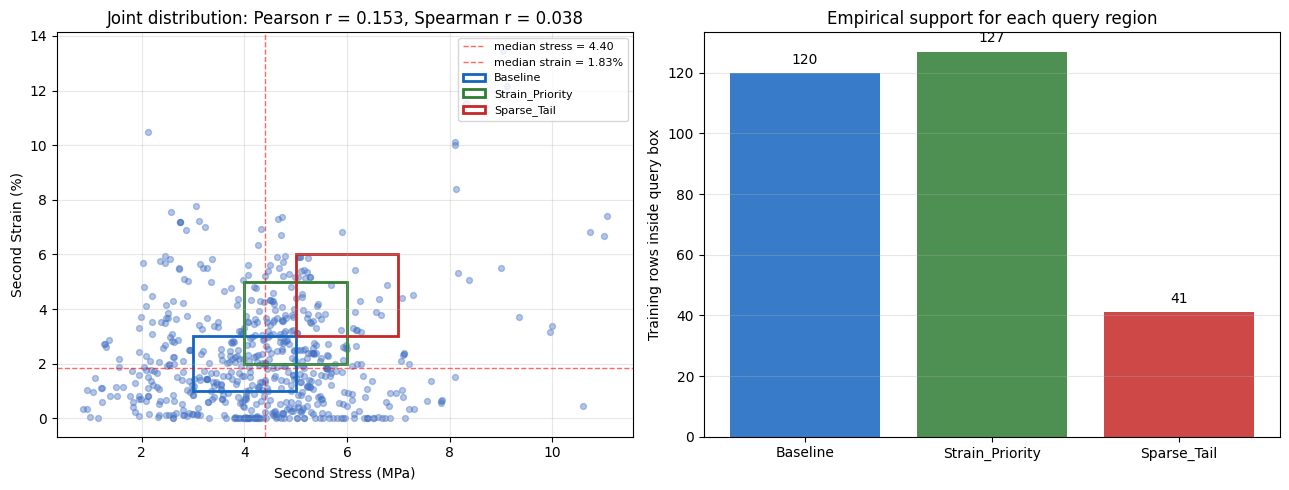

In [4]:
from scipy.stats import pearsonr, spearmanr

both = df[['Second Stress', 'Second Strain']].dropna()
s_obs, e_obs = both['Second Stress'].values, both['Second Strain'].values

pr, pp = pearsonr(s_obs, e_obs)
sr, sp = spearmanr(s_obs, e_obs)

print(f"Joint stress-strain distribution analysis (N = {len(both)})")
print(f"  Pearson  r = {pr:.3f}  (p = {pp:.2e})")
print(f"  Spearman r = {sr:.3f}  (p = {sp:.2e})")
print(f"  Interpretation: stress and strain are essentially uncorrelated "
      f"({pr**2*100:.1f}% shared variance)")

# Quadrant analysis around medians
s_med, e_med = np.median(s_obs), np.median(e_obs)
q1 = ((s_obs >= s_med) & (e_obs >= e_med)).sum()
q2 = ((s_obs <  s_med) & (e_obs >= e_med)).sum()
q3 = ((s_obs <  s_med) & (e_obs <  e_med)).sum()
q4 = ((s_obs >= s_med) & (e_obs <  e_med)).sum()
n = len(both)
print(f"\nQuadrant breakdown (around medians: stress={s_med:.2f} MPa, strain={e_med*100:.2f}%):")
print(f"  HIGH-stress + HIGH-strain : {q1:3d}  ({100*q1/n:.1f}%)")
print(f"  LOW-stress  + HIGH-strain : {q2:3d}  ({100*q2/n:.1f}%)")
print(f"  LOW-stress  + LOW-strain  : {q3:3d}  ({100*q3/n:.1f}%)")
print(f"  HIGH-stress + LOW-strain  : {q4:3d}  ({100*q4/n:.1f}%)")
print(f"  (Roughly 25% each = independent; 50/0/0/50 would be perfect coupling)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(s_obs, e_obs*100, alpha=0.4, s=18, color='#4472C4')
ax.axvline(s_med, color='red', ls='--', lw=1, alpha=0.6, label=f'median stress = {s_med:.2f}')
ax.axhline(e_med*100, color='red', ls='--', lw=1, alpha=0.6, label=f'median strain = {e_med*100:.2f}%')
# Overlay test query boxes
test_boxes = [
    ('Baseline',        (3.0, 5.0), (1.0, 3.0), '#1565C0'),
    ('Strain_Priority', (4.0, 6.0), (2.0, 5.0), '#2E7D32'),
    ('Sparse_Tail',     (5.0, 7.0), (3.0, 6.0), '#C62828'),
]
for name, sr_, er_, col in test_boxes:
    ax.add_patch(plt.Rectangle((sr_[0], er_[0]), sr_[1]-sr_[0], er_[1]-er_[0],
                               fill=False, ec=col, lw=2.0, label=name))
ax.set_xlabel('Second Stress (MPa)'); ax.set_ylabel('Second Strain (%)')
ax.set_title(f'Joint distribution: Pearson r = {pr:.3f}, Spearman r = {sr:.3f}')
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)

# Side: count of training rows inside each query box
ax = axes[1]
labels, counts, colors = [], [], []
for name, sr_, er_, col in test_boxes:
    in_box = ((s_obs >= sr_[0]) & (s_obs <= sr_[1]) &
              (e_obs >= er_[0]/100) & (e_obs <= er_[1]/100)).sum()
    labels.append(name); counts.append(in_box); colors.append(col)
bars = ax.bar(labels, counts, color=colors, alpha=0.85)
for b, c in zip(bars, counts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3, str(c),
            ha='center', fontsize=10)
ax.set_ylabel('Training rows inside query box')
ax.set_title('Empirical support for each query region')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'stress_strain_decoupling.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. CatBoost Mondrian-CQR cross-validation (diagnostic)

Trains q10/q50/q90 CatBoost regressors and applies Mondrian CQR calibration via 5-fold GroupKFold. Reports MAE / RMSE / R² / Cov80 / Width80 on the 32-feature set. This is a forward-model diagnostic only — the inverse pipeline refits its own models in section 3 with a held-out calibration split.

In [5]:
CB_PARAMS_STRAIN = {
    "iterations": 600,
    "depth": 9,
    "learning_rate": 0.12604670759479358,
    "l2_leaf_reg": 0.2919794366938302,
    "random_seed": RANDOM_STATE,
    "verbose": 0
}

CB_PARAMS_STRESS = {
    "iterations": 800,
    "depth": 10,
    "learning_rate": 0.03156119992394155,
    "l2_leaf_reg": 0.20410490729823838,
    "random_seed": RANDOM_STATE,
    "verbose": 0,       
}

REGIME_CUTOFFS = {
    "Second Strain": (0.005, 0.050, 0.0015),
    "Second Stress": (4.0, 5.13, 0.20),
}
REGIME_NAMES = {
    "Second Strain": ("NoPSH", "Bulk", "Tail"),
    "Second Stress": ("Weak", "Mid", "Strong"),
}


def make_catboost_quantile(alpha, target):
    params = CB_PARAMS_STRESS if target == "Second Stress" else CB_PARAMS_STRAIN
    return CatBoostRegressor(loss_function=f"Quantile:alpha={alpha}", **params)


def build_group_means(df_in, target):
    g = df_in.groupby("group_id").agg(
        **{col: (col, "mean") for col in FEATURES_32 + [target]},
        n_rep=("group_id", "count"),
        tgt_var=(target, "var"),
    ).reset_index()
    g["tgt_var"] = g["tgt_var"].fillna(0.0)
    g["sample_weight"] = g["n_rep"] / (g["tgt_var"] + 0.1)

    c1, c2, _ = REGIME_CUTOFFS[target]
    low, mid, high = REGIME_NAMES[target]
    y = g[target].values
    g["regime"] = np.where(y < c1, low, np.where(y < c2, mid, high))
    return g


def mondrian_qhat(cal_scores, cal_q50_pred, val_q50_pred, alpha=0.20):
    """Per-bin conformal qhat across three quantile bins of cal_q50_pred."""
    q33 = np.quantile(cal_q50_pred, 1/3)
    q67 = np.quantile(cal_q50_pred, 2/3)
    cb = np.where(cal_q50_pred <= q33, 0, np.where(cal_q50_pred <= q67, 1, 2))
    vb = np.where(val_q50_pred <= q33, 0, np.where(val_q50_pred <= q67, 1, 2))

    out = np.zeros(len(val_q50_pred))
    for b in range(3):
        mc = cb == b
        mv = vb == b
        n_b = mc.sum()
        if n_b == 0:
            out[mv] = np.quantile(cal_scores, 1 - alpha) if len(cal_scores) else 0
        else:
            lvl = min(np.ceil((n_b + 1) * (1 - alpha)) / n_b, 1.0)
            out[mv] = np.quantile(cal_scores[mc], lvl)
    return out


def fit_predict_catboost(X_train, y_train, w_train, X_pred, target):
    m50 = make_catboost_quantile(0.50, target)
    m50.fit(X_train, y_train, sample_weight=w_train)
    q50 = m50.predict(X_pred)

    m10 = make_catboost_quantile(0.10, target)
    m10.fit(X_train, y_train, sample_weight=w_train)
    q10 = m10.predict(X_pred)

    m90 = make_catboost_quantile(0.90, target)
    m90.fit(X_train, y_train, sample_weight=w_train)
    q90 = m90.predict(X_pred)

    return q10, q50, q90


def run_catboost_mondrian_cv(g, target, alpha=0.20):
    y_all = g[target].values
    groups_arr = g["group_id"].values
    gkf = GroupKFold(n_splits=5)

    N = len(g)
    p50 = np.full(N, np.nan)
    lo  = np.full(N, np.nan)
    hi  = np.full(N, np.nan)

    for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(g, y_all, groups_arr), start=1):
        g_tr = g.iloc[tr_idx].reset_index(drop=True)
        g_va = g.iloc[val_idx].reset_index(drop=True)

        y_tr = g_tr[target].values
        w_tr = g_tr["sample_weight"].values

        tr_uniq = g_tr["group_id"].unique()
        rng = np.random.default_rng(fold_idx)
        rng.shuffle(tr_uniq)
        n_fit = int(0.75 * len(tr_uniq))
        fit_grp = set(tr_uniq[:n_fit])

        fit_mask = g_tr["group_id"].isin(fit_grp).values

        X_tr  = g_tr[FEATURES_32].values
        X_fit = g_tr.loc[fit_mask, FEATURES_32].values
        X_cal = g_tr.loc[~fit_mask, FEATURES_32].values
        X_va  = g_va[FEATURES_32].values

        y_fit = y_tr[fit_mask]
        y_cal = y_tr[~fit_mask]
        w_fit = w_tr[fit_mask]

        q10_va, q50_va, q90_va = fit_predict_catboost(X_tr, y_tr, w_tr, X_va, target)
        q10_cal, q50_cal, q90_cal = fit_predict_catboost(X_fit, y_fit, w_fit, X_cal, target)
        _, q50_va_fit, _ = fit_predict_catboost(X_fit, y_fit, w_fit, X_va, target)

        scores = np.maximum(q10_cal - y_cal, y_cal - q90_cal)
        qhat = mondrian_qhat(scores, q50_cal, q50_va_fit, alpha)

        p50[val_idx] = np.maximum(q50_va, 0)
        lo[val_idx]  = np.maximum(q10_va - qhat, 0)
        hi[val_idx]  = np.maximum(q90_va + qhat, 0)

    # Enforce monotonicity (CatBoost quantile crossing can flip lo/hi)
    lo = np.minimum(lo, p50)
    hi = np.maximum(hi, p50)

    y_true = g[target].values
    metrics = {
        "MAE":   mean_absolute_error(y_true, p50),
        "RMSE":  np.sqrt(mean_squared_error(y_true, p50)),
        "R2":    r2_score(y_true, p50),
        "Cov80": np.mean((y_true >= lo) & (y_true <= hi)),
        "Width80": np.mean(hi - lo),
    }
    return metrics, p50, lo, hi


# Run for both targets
ALL_RESULTS = {}
for target in TARGETS:
    g = build_group_means(df, target)
    metrics, p50, lo, hi = run_catboost_mondrian_cv(g, target, alpha=0.20)
    ALL_RESULTS[target] = {"group_df": g, "metrics": metrics,
                           "p50": p50, "lo": lo, "hi": hi}
    print(f"{target} -> MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, "
          f"R2={metrics['R2']:.4f}, Cov80={metrics['Cov80']:.3f}, "
          f"Width80={metrics['Width80']:.4f}")

Second Stress -> MAE=0.5292, RMSE=0.7621, R2=0.7238, Cov80=0.862, Width80=2.1387
Second Strain -> MAE=0.0073, RMSE=0.0120, R2=0.5698, Cov80=0.866, Width80=0.0307


In [6]:
# ============================================================
# Section 1.6 — PCA component sweep (R² as selection metric)
# ------------------------------------------------------------
# Fits StandardScaler + PCA INSIDE each GroupKFold fold to
# avoid leakage. Sweeps k = 2..32 and reports CV R² (q50) on
# the chosen target. Uses reduced iterations for sweep speed;
# refit at chosen k with full params for the final number.
# ============================================================

from sklearn.decomposition import PCA

SWEEP_TARGET = "Second Stress"     # flip to "Second Strain" if you want
K_GRID = list(range(2, 33))         # 2..32
SWEEP_ITERS = 300                   # reduced from 600/800 for sweep speed
ALPHA_PI = 0.20

# Lighter params for the sweep — keeps depth/lr/l2 from your tuned config
def _make_q_sweep(alpha, target):
    base = CB_PARAMS_STRESS if target == "Second Stress" else CB_PARAMS_STRAIN
    p = {**base, "iterations": SWEEP_ITERS}
    return CatBoostRegressor(loss_function=f"Quantile:alpha={alpha}", **p)


def _fit_predict_q_sweep(Xtr, ytr, wtr, Xpred, target):
    preds = []
    for a in (0.10, 0.50, 0.90):
        m = _make_q_sweep(a, target)
        m.fit(Xtr, ytr, sample_weight=wtr)
        preds.append(m.predict(Xpred))
    return preds  # [q10, q50, q90]


def pca_cv_r2(g, target, k, alpha=ALPHA_PI):
    """Run Mondrian-CQR CV on the GROUP-MEAN frame with PCA(k) inside each fold."""
    y_all = g[target].values
    groups_arr = g["group_id"].values
    gkf = GroupKFold(n_splits=5)

    N = len(g)
    p50 = np.full(N, np.nan)
    lo = np.full(N, np.nan)
    hi = np.full(N, np.nan)

    for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(g, y_all, groups_arr), start=1):
        g_tr = g.iloc[tr_idx].reset_index(drop=True)
        g_va = g.iloc[val_idx].reset_index(drop=True)

        y_tr = g_tr[target].values
        w_tr = g_tr["sample_weight"].values

        # inner fit/calibration split on TRAINING groups only
        tr_uniq = g_tr["group_id"].unique()
        rng = np.random.default_rng(fold_idx)
        rng.shuffle(tr_uniq)
        n_fit = int(0.75 * len(tr_uniq))
        fit_grp = set(tr_uniq[:n_fit])
        fit_mask = g_tr["group_id"].isin(fit_grp).values

        # ---- Scale + PCA fitted on TRAIN fold only (no leakage) ----
        Xtr_raw = g_tr[FEATURES_32].values
        Xva_raw = g_va[FEATURES_32].values

        scaler = StandardScaler().fit(Xtr_raw)
        Xtr_s = scaler.transform(Xtr_raw)
        Xva_s = scaler.transform(Xva_raw)

        pca = PCA(n_components=k, random_state=RANDOM_STATE).fit(Xtr_s)
        Xtr_p = pca.transform(Xtr_s)
        Xva_p = pca.transform(Xva_s)

        X_fit = Xtr_p[fit_mask]
        X_cal = Xtr_p[~fit_mask]
        y_fit = y_tr[fit_mask]
        y_cal = y_tr[~fit_mask]
        w_fit = w_tr[fit_mask]

        q10_va, q50_va, q90_va = _fit_predict_q_sweep(Xtr_p, y_tr, w_tr, Xva_p, target)
        q10_cal, q50_cal, q90_cal = _fit_predict_q_sweep(X_fit, y_fit, w_fit, X_cal, target)
        _, q50_va_fit, _ = _fit_predict_q_sweep(X_fit, y_fit, w_fit, Xva_p, target)

        scores = np.maximum(q10_cal - y_cal, y_cal - q90_cal)
        qhat = mondrian_qhat(scores, q50_cal, q50_va_fit, alpha)

        p50[val_idx] = np.maximum(q50_va, 0)
        lo[val_idx] = np.maximum(q10_va - qhat, 0)
        hi[val_idx] = np.maximum(q90_va + qhat, 0)

    lo = np.minimum(lo, p50)
    hi = np.maximum(hi, p50)

    y_true = g[target].values
    return {
        "k": k,
        "R2": r2_score(y_true, p50),
        "MAE": mean_absolute_error(y_true, p50),
        "RMSE": np.sqrt(mean_squared_error(y_true, p50)),
        "Cov80": np.mean((y_true >= lo) & (y_true <= hi)),
        "Width80": np.mean(hi - lo),
    }


# ---- Run the sweep ----------------------------------------
g_sweep = build_group_means(df, SWEEP_TARGET)

sweep_rows = []
print(f"PCA sweep on '{SWEEP_TARGET}'  (sweep iters={SWEEP_ITERS})")
print(f"{'k':>3} {'R2':>8} {'MAE':>8} {'RMSE':>8} {'Cov80':>7} {'Width80':>8}")
print("-" * 50)
for k in K_GRID:
    res = pca_cv_r2(g_sweep, SWEEP_TARGET, k)
    sweep_rows.append(res)
    print(f"{k:>3} {res['R2']:>8.4f} {res['MAE']:>8.4f} {res['RMSE']:>8.4f} "
          f"{res['Cov80']:>7.3f} {res['Width80']:>8.4f}")

pca_sweep_df = pd.DataFrame(sweep_rows)
pca_sweep_df.to_csv(RESULTS_DIR / "pca_sweep.csv", index=False)

# Baseline (no PCA, full 32 features, sweep-iter config) for fair comparison
# Re-uses run_catboost_mondrian_cv but with reduced iters via a temporary monkeypatch
_orig_make = make_catboost_quantile
def _sweep_make(alpha, target):
    base = CB_PARAMS_STRESS if target == "Second Stress" else CB_PARAMS_STRAIN
    return CatBoostRegressor(loss_function=f"Quantile:alpha={alpha}",
                             **{**base, "iterations": SWEEP_ITERS})
make_catboost_quantile = _sweep_make
try:
    baseline_metrics, *_ = run_catboost_mondrian_cv(g_sweep, SWEEP_TARGET, alpha=ALPHA_PI)
finally:
    make_catboost_quantile = _orig_make
print()
print(f"Baseline (no PCA, 32 feats, {SWEEP_ITERS} iters): "
      f"R2={baseline_metrics['R2']:.4f}, MAE={baseline_metrics['MAE']:.4f}, "
      f"RMSE={baseline_metrics['RMSE']:.4f}")

# ---- Plot R² vs k -----------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(pca_sweep_df["k"], pca_sweep_df["R2"], "o-", color="#4472C4", label=f"PCA-{SWEEP_TARGET}")
ax.axhline(baseline_metrics["R2"], color="red", ls="--", lw=1.2,
           label=f"No PCA (32 feats) = {baseline_metrics['R2']:.3f}")
best_k = int(pca_sweep_df.loc[pca_sweep_df["R2"].idxmax(), "k"])
best_r2 = pca_sweep_df["R2"].max()
ax.axvline(best_k, color="green", ls=":", lw=1.0,
           label=f"argmax k={best_k}, R²={best_r2:.3f}")
ax.set_xlabel("Number of PCA components (k)")
ax.set_ylabel("CV R² (q50)")
ax.set_title(f"PCA component sweep — {SWEEP_TARGET}")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_sweep_r2.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print(f"Best k by CV R²: {best_k} (R²={best_r2:.4f})")
print(f"Δ vs no-PCA baseline: {best_r2 - baseline_metrics['R2']:+.4f}")


PCA sweep on 'Second Stress'  (sweep iters=300)
  k       R2      MAE     RMSE   Cov80  Width80
--------------------------------------------------
  2   0.3976   0.8011   1.1255   0.888   3.2222
  3   0.5542   0.6703   0.9682   0.873   2.8704
  4   0.6222   0.6068   0.8913   0.841   2.6029
  5   0.6666   0.5795   0.8373   0.891   2.5940
  6   0.6719   0.5739   0.8306   0.873   2.3227
  7   0.6925   0.5541   0.8041   0.862   2.3518
  8   0.6816   0.5658   0.8182   0.862   2.2959
  9   0.6790   0.5627   0.8216   0.862   2.3546
 10   0.6932   0.5536   0.8032   0.859   2.2946
 11   0.6809   0.5605   0.8192   0.859   2.2898
 12   0.6705   0.5673   0.8324   0.873   2.4407
 13   0.6808   0.5571   0.8193   0.877   2.4046
 14   0.6797   0.5461   0.8207   0.888   2.5160
 15   0.6676   0.5682   0.8361   0.906   2.5134
 16   0.6687   0.5484   0.8346   0.851   2.4986
 17   0.6713   0.5605   0.8314   0.873   2.3822
 18   0.6604   0.5735   0.8450   0.880   2.3798
 19   0.6540   0.5694   0.8529   0.88

KeyboardInterrupt: 

In [ ]:
# ============================================================
# Section 1.7 — VIF-based multicollinearity pruning
# ------------------------------------------------------------
# Iteratively drop the feature with highest VIF until all
# remaining features have VIF <= VIF_THRESHOLD. Reports the
# surviving feature list and re-runs CV with that subset.
# ============================================================
from sklearn.linear_model import LinearRegression

VIF_THRESHOLD = 10.0   # standard rule-of-thumb (5 = strict, 10 = lenient)

def compute_vif(X_df):
    """Compute VIF for each column in X_df. Returns pd.Series indexed by feature."""
    X = X_df.values
    vifs = {}
    for j, col in enumerate(X_df.columns):
        Xj = X[:, j]
        X_others = np.delete(X, j, axis=1)
        # Guard against constant columns
        if np.std(Xj) < 1e-12 or X_others.shape[1] == 0:
            vifs[col] = np.inf
            continue
        r2 = LinearRegression().fit(X_others, Xj).score(X_others, Xj)
        vifs[col] = 1.0 / max(1 - r2, 1e-12)
    return pd.Series(vifs).sort_values(ascending=False)


# Standardize before VIF — scale doesn't change VIF mathematically, but
# avoids numerical blow-up from mixed-unit features.
X_full = df[FEATURES_32].copy()
scaler_vif = StandardScaler().fit(X_full.values)
X_std = pd.DataFrame(scaler_vif.transform(X_full.values), columns=FEATURES_32)

dropped_log = []
current_cols = list(FEATURES_32)

while True:
    vifs = compute_vif(X_std[current_cols])
    worst_feat = vifs.index[0]
    worst_vif = vifs.iloc[0]
    if worst_vif <= VIF_THRESHOLD or len(current_cols) <= 2:
        break
    dropped_log.append((worst_feat, worst_vif))
    current_cols.remove(worst_feat)

FEATURES_VIF = current_cols
print(f"VIF pruning (threshold={VIF_THRESHOLD})")
print(f"  Started with: {len(FEATURES_32)} features")
print(f"  Dropped {len(dropped_log)} features:")
for feat, v in dropped_log:
    print(f"    - {feat:30s}  VIF was {v:>10.1f}")
print(f"  Surviving: {len(FEATURES_VIF)} features")

final_vifs = compute_vif(X_std[FEATURES_VIF])
print()
print(f"  Max VIF after pruning: {final_vifs.iloc[0]:.2f}  ({final_vifs.index[0]})")
print(f"  Median VIF after pruning: {final_vifs.median():.2f}")

# ---- Re-run CV on the VIF-pruned feature set --------------
# Temporarily swap FEATURES_32 -> FEATURES_VIF inside the existing CV machinery
_orig_features = FEATURES_32
FEATURES_32 = FEATURES_VIF       # build_group_means / run_catboost_mondrian_cv read this

try:
    print()
    print(f"Re-running CV with VIF-pruned feature set ({len(FEATURES_VIF)} features)...")
    VIF_RESULTS = {}
    for target in TARGETS:
        g = build_group_means(df, target)
        metrics, p50, lo, hi = run_catboost_mondrian_cv(g, target, alpha=0.20)
        VIF_RESULTS[target] = metrics
        print(f"  {target:>14s} -> R²={metrics['R2']:.4f}  MAE={metrics['MAE']:.4f}  "
              f"RMSE={metrics['RMSE']:.4f}  Cov80={metrics['Cov80']:.3f}")
finally:
    FEATURES_32 = _orig_features     # restore

# ---- Comparison table -------------------------------------
print()
print("=" * 70)
print("FEATURE-SET COMPARISON")
print("=" * 70)
print(f"{'Set':<25} {'#feats':>7} {'Stress R²':>10} {'Strain R²':>10}")
print("-" * 70)
print(f"{'Reduced A (current)':<25} {len(_orig_features):>7} "
      f"{ALL_RESULTS['Second Stress']['metrics']['R2']:>10.4f} "
      f"{ALL_RESULTS['Second Strain']['metrics']['R2']:>10.4f}")
print(f"{'VIF-pruned':<25} {len(FEATURES_VIF):>7} "
      f"{VIF_RESULTS['Second Stress']['R2']:>10.4f} "
      f"{VIF_RESULTS['Second Strain']['R2']:>10.4f}")
print("=" * 70)


## 3. Forward-model diagnostic plots

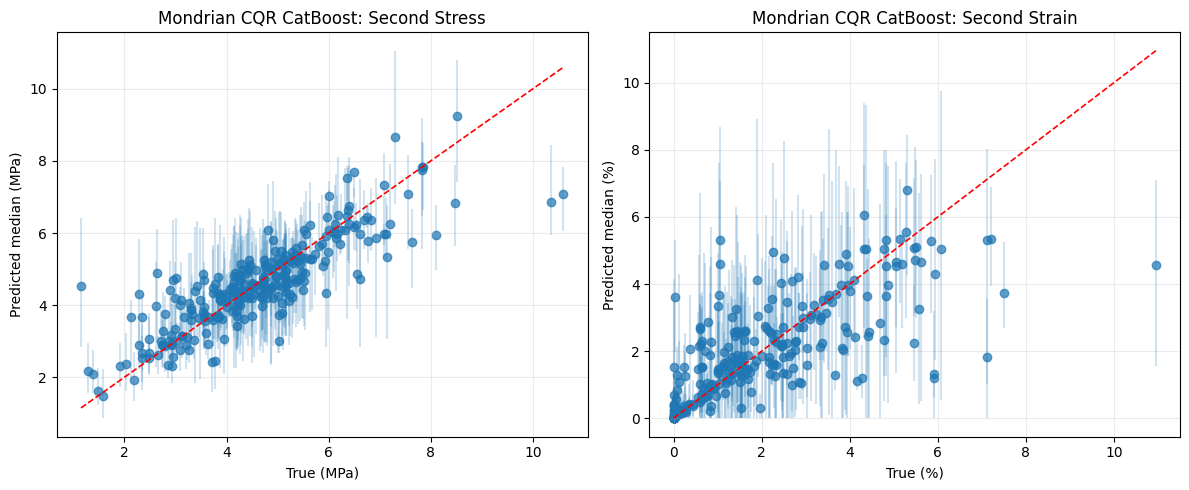

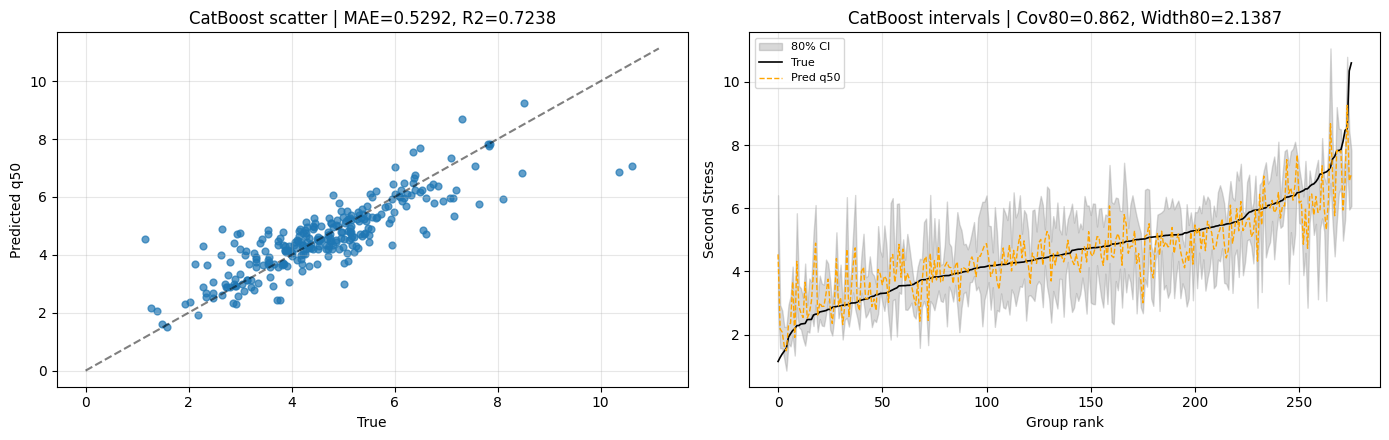

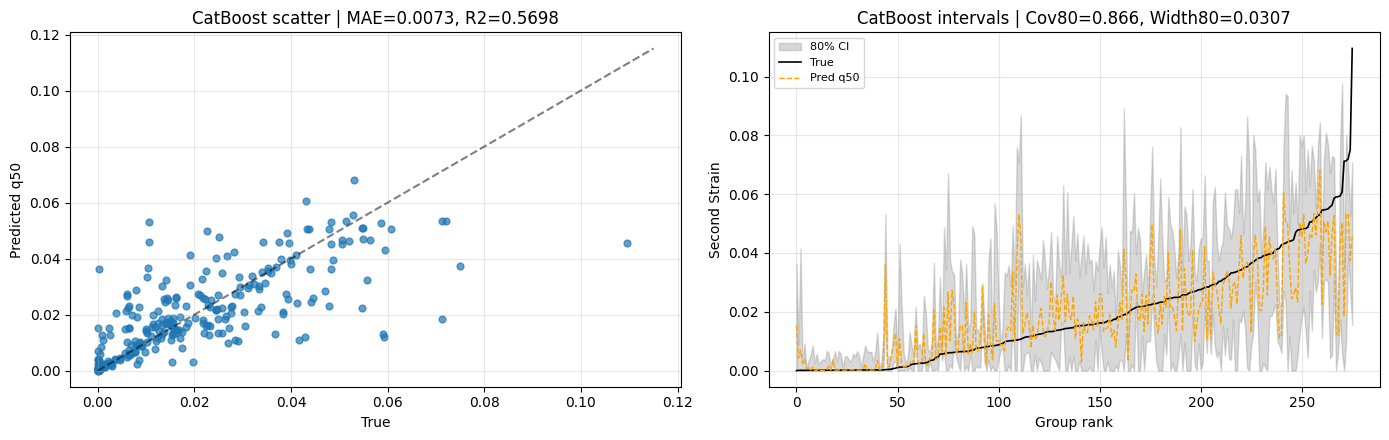

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target, unit_mult, unit in [
    (axes[0], "Second Stress", 1.0, "MPa"),
    (axes[1], "Second Strain", 100.0, "%"),
]:
    g  = ALL_RESULTS[target]["group_df"]
    y  = g[target].values * unit_mult
    p  = ALL_RESULTS[target]["p50"] * unit_mult
    lo = ALL_RESULTS[target]["lo"]  * unit_mult
    hi = ALL_RESULTS[target]["hi"]  * unit_mult

    ax.scatter(y, p, alpha=0.7)
    ax.vlines(y, lo, hi, alpha=0.2)
    lim0, lim1 = min(y.min(), p.min()), max(y.max(), p.max())
    ax.plot([lim0, lim1], [lim0, lim1], 'r--', lw=1.2)
    ax.set_title(f"Mondrian CQR CatBoost: {target}")
    ax.set_xlabel(f"True ({unit})")
    ax.set_ylabel(f"Predicted median ({unit})")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "scatter_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


def plot_catboost_backend_style(target):
    g   = ALL_RESULTS[target]["group_df"]
    m   = ALL_RESULTS[target]["metrics"]
    p50 = ALL_RESULTS[target]["p50"]
    lo  = ALL_RESULTS[target]["lo"]
    hi  = ALL_RESULTS[target]["hi"]
    y_true = g[target].values
    sort_idx = np.argsort(y_true)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    ax = axes[0]
    ax.scatter(y_true, p50, s=24, alpha=0.7)
    lim = max(np.max(y_true), np.max(p50)) * 1.05
    ax.plot([0, lim], [0, lim], "k--", alpha=0.5)
    ax.set_title(f"CatBoost scatter | MAE={m['MAE']:.4f}, R2={m['R2']:.4f}")
    ax.set_xlabel("True"); ax.set_ylabel("Predicted q50")
    ax.grid(alpha=0.3)

    ax = axes[1]
    x = np.arange(len(y_true))
    ax.fill_between(x, lo[sort_idx], hi[sort_idx], color="gray", alpha=0.3, label="80% CI")
    ax.plot(x, y_true[sort_idx], "k-", lw=1.2, label="True")
    ax.plot(x, p50[sort_idx], color="orange", lw=1.0, ls="--", label="Pred q50")
    ax.set_title(f"CatBoost intervals | Cov80={m['Cov80']:.3f}, Width80={m['Width80']:.4f}")
    ax.set_xlabel("Group rank"); ax.set_ylabel(target)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    safe = target.replace(" ", "_")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"catboost_{safe}_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_catboost_backend_style("Second Stress")
plot_catboost_backend_style("Second Strain")

In [11]:
# ── CELL A: R² CEILING ────────────────────────────────────────────────────────
print("=" * 60)
print("R² CEILING ANALYSIS")
print("=" * 60)
print("Quantifies the maximum achievable R² given irreducible")
print("within-group variance from replicate specimens.")
print()

for target in ["Second Stress", "Second Strain"]:
    group_stats = df.groupby("group_id")[target].agg(["var", "count"]).fillna(0)
    mean_within_var = (
        (group_stats["var"] * group_stats["count"]).sum()
        / group_stats["count"].sum()
    )
    total_var  = df[target].var()
    ceiling    = 1.0 - (mean_within_var / total_var)
    model_r2   = ALL_RESULTS[target]["metrics"]["R2"]
    efficiency = model_r2 / ceiling if ceiling > 0 else 0.0

    print(f"  {target}")
    print(f"    R² ceiling (theoretical max) : {ceiling:.4f}")
    print(f"    Model R²   (GroupKFold CV)   : {model_r2:.4f}")
    print(f"    Model efficiency             : {efficiency:.1%} of ceiling")
    if efficiency > 0.90:
        print(f"    → Near-optimal. Remaining gap requires unmeasured")
        print(f"      covariates (fiber dispersion, curing conditions).")
    elif efficiency > 0.75:
        print(f"    → Moderate gap. More data or features may help.")
    else:
        print(f"    → Meaningful gap. Architecture or feature improvements")
        print(f"      likely to yield gains.")
    print()

R² CEILING ANALYSIS
Quantifies the maximum achievable R² given irreducible
within-group variance from replicate specimens.

  Second Stress
    R² ceiling (theoretical max) : 0.9056
    Model R²   (GroupKFold CV)   : 0.7238
    Model efficiency             : 79.9% of ceiling
    → Moderate gap. More data or features may help.

  Second Strain
    R² ceiling (theoretical max) : 0.7608
    Model R²   (GroupKFold CV)   : 0.5698
    Model efficiency             : 74.9% of ceiling
    → Meaningful gap. Architecture or feature improvements
      likely to yield gains.



Running fold-saving CV (one pass per target)...

  Second Stress:
    Fold 1/5...
    Fold 2/5...
    Fold 3/5...
    Fold 4/5...
    Fold 5/5...

  Second Strain:
    Fold 1/5...
    Fold 2/5...
    Fold 3/5...
    Fold 4/5...
    Fold 5/5...

Sweeping alpha levels post-hoc...


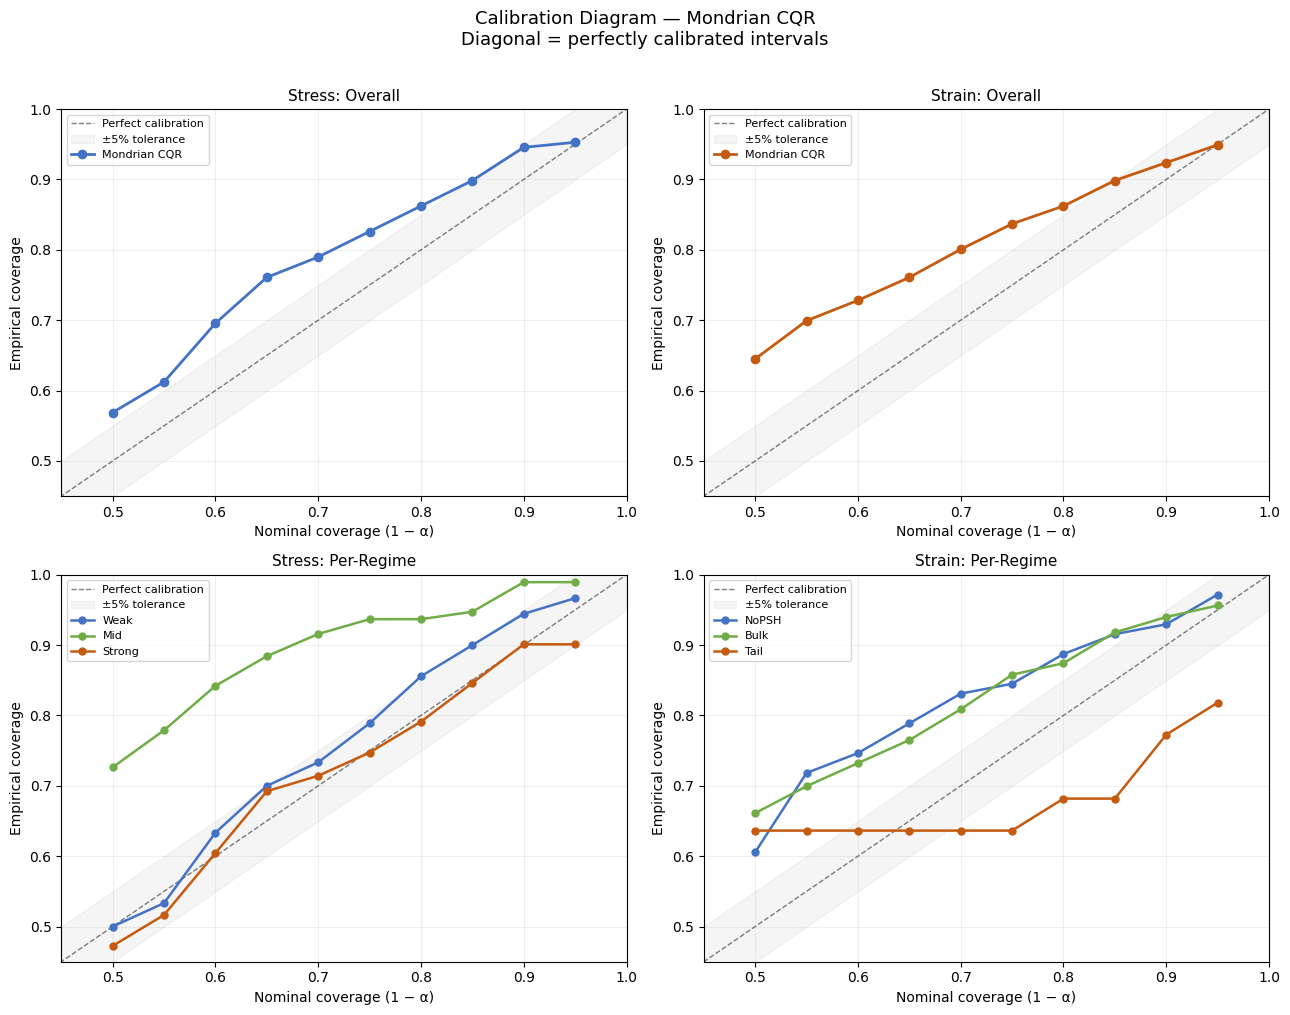

Saved: calibration_diagram.png

Calibration check:
Target                Nominal  Empirical        Δ   OK?
-------------------------------------------------------
  Second Stress          0.90     0.9457  +0.0457     ✓
  Second Stress          0.80     0.8623  +0.0623     ✗
  Second Stress          0.70     0.7899  +0.0899     ✗
  Second Strain          0.90     0.9239  +0.0239     ✓
  Second Strain          0.80     0.8623  +0.0623     ✗
  Second Strain          0.70     0.8007  +0.1007     ✗


In [28]:
# ── CELL B: CALIBRATION DIAGRAM ───────────────────────────────────────────────


from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt

def run_cv_save_folds(g, target):
    y_all      = g[target].values
    groups_arr = g["group_id"].values
    gkf        = GroupKFold(n_splits=5)
    fold_data  = []

    for fold_idx, (tr_idx, val_idx) in enumerate(
            gkf.split(g, y_all, groups_arr), start=1):
        print(f"    Fold {fold_idx}/5...", flush=True)
        g_tr = g.iloc[tr_idx].reset_index(drop=True)
        g_va = g.iloc[val_idx].reset_index(drop=True)
        y_tr = g_tr[target].values
        w_tr = g_tr["sample_weight"].values

        tr_uniq  = g_tr["group_id"].unique()
        rng      = np.random.default_rng(fold_idx)
        rng.shuffle(tr_uniq)
        fit_grp  = set(tr_uniq[:int(0.75 * len(tr_uniq))])
        fit_mask = g_tr["group_id"].isin(fit_grp).values
        cal_mask = ~fit_mask

        X_tr  = g_tr[FEATURES_32].values
        X_fit = g_tr.loc[fit_mask, FEATURES_32].values
        X_cal = g_tr.loc[cal_mask, FEATURES_32].values
        X_va  = g_va[FEATURES_32].values
        y_fit = y_tr[fit_mask]
        y_cal = y_tr[cal_mask]
        w_fit = w_tr[fit_mask]

        m50f = make_catboost_quantile(0.50, target); m50f.fit(X_tr, y_tr, sample_weight=w_tr)
        m10f = make_catboost_quantile(0.10, target); m10f.fit(X_tr, y_tr, sample_weight=w_tr)
        m90f = make_catboost_quantile(0.90, target); m90f.fit(X_tr, y_tr, sample_weight=w_tr)

        m50c = make_catboost_quantile(0.50, target); m50c.fit(X_fit, y_fit, sample_weight=w_fit)
        m10c = make_catboost_quantile(0.10, target); m10c.fit(X_fit, y_fit, sample_weight=w_fit)
        m90c = make_catboost_quantile(0.90, target); m90c.fit(X_fit, y_fit, sample_weight=w_fit)

        cal_scores  = np.maximum(m10c.predict(X_cal) - y_cal,
                                  y_cal - m90c.predict(X_cal))
        q50_cal_fit = m50c.predict(X_cal)
        q50_va_fit  = m50c.predict(X_va)
        q10_va      = m10f.predict(X_va)
        q50_va      = m50f.predict(X_va)
        q90_va      = m90f.predict(X_va)

        c1, c2, _   = REGIME_CUTOFFS[target]
        low, mid, high = REGIME_NAMES[target]
        regime_va   = np.where(
            g_va[target].values < c1, low,
            np.where(g_va[target].values < c2, mid, high)
        )

        fold_data.append({
            "y_val":      g_va[target].values,
            "regime_val": regime_va,
            "cal_scores": cal_scores,
            "q50_cal":    q50_cal_fit,
            "q10_va":     q10_va,
            "q50_va":     q50_va,
            "q90_va":     q90_va,
            "q50_va_fit": q50_va_fit,
        })
    return fold_data


def coverage_at_alpha(fold_data, target, alpha):
    low_r, mid_r, high_r = REGIME_NAMES[target]
    all_in = []
    reg_in = {low_r: [], mid_r: [], high_r: []}

    for fd in fold_data:
        qhat   = mondrian_qhat(fd["cal_scores"], fd["q50_cal"],
                                fd["q50_va_fit"], alpha)
        lo     = np.maximum(fd["q10_va"] - qhat, 0)
        hi     = np.maximum(fd["q90_va"] + qhat, 0)
        inside = (fd["y_val"] >= lo) & (fd["y_val"] <= hi)
        all_in.extend(inside.tolist())
        for r in [low_r, mid_r, high_r]:
            mask = fd["regime_val"] == r
            if mask.sum() > 0:
                reg_in[r].extend(inside[mask].tolist())

    result = {"overall": np.mean(all_in)}
    for r in [low_r, mid_r, high_r]:
        result[r] = np.mean(reg_in[r]) if reg_in[r] else np.nan
    return result


print("Running fold-saving CV (one pass per target)...")
fold_data_all = {}
for target in ["Second Stress", "Second Strain"]:
    g = build_group_means(df, target)
    print(f"\n  {target}:")
    fold_data_all[target] = run_cv_save_folds(g, target)

alphas         = np.array([0.05, 0.10, 0.15, 0.20, 0.25,
                            0.30, 0.35, 0.40, 0.45, 0.50])
nominal_levels = 1 - alphas

print("\nSweeping alpha levels post-hoc...")
coverage_results = {}
for target in ["Second Stress", "Second Strain"]:
    coverage_results[target] = {
        a: coverage_at_alpha(fold_data_all[target], target, a)
        for a in alphas
    }

regime_colors = {
    "Weak":  "#4472C4", "Mid":   "#70AD47", "Strong": "#C55A11",
    "NoPSH": "#4472C4", "Bulk":  "#70AD47", "Tail":   "#C55A11",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Calibration Diagram — Mondrian CQR\n"
             "Diagonal = perfectly calibrated intervals",
             fontsize=13, y=1.01)

for ax, target, regime_key, title, color in [
    (axes[0, 0], "Second Stress", "overall",    "Stress: Overall",    "#4472C4"),
    (axes[0, 1], "Second Strain", "overall",    "Strain: Overall",    "#C55A11"),
    (axes[1, 0], "Second Stress", "per_regime", "Stress: Per-Regime", None),
    (axes[1, 1], "Second Strain", "per_regime", "Strain: Per-Regime", None),
]:
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Perfect calibration")
    ax.fill_between([0.45, 1], [0.40, 0.95], [0.50, 1.05],
                    alpha=0.08, color="gray", label="±5% tolerance")

    if regime_key == "overall":
        emps = [coverage_results[target][a]["overall"] for a in alphas]
        ax.plot(nominal_levels, emps, "o-", color=color,
                ms=6, lw=2, label="Mondrian CQR")
    else:
        for r, rc in regime_colors.items():
            if r in REGIME_NAMES[target]:
                emps = [coverage_results[target][a].get(r, np.nan) for a in alphas]
                if not all(np.isnan(emps)):
                    ax.plot(nominal_levels, emps, "o-", color=rc,
                            ms=5, lw=1.8, label=r)

    ax.set_xlabel("Nominal coverage (1 − α)", fontsize=10)
    ax.set_ylabel("Empirical coverage",        fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0.45, 1.0); ax.set_ylim(0.45, 1.0)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("calibration_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: calibration_diagram.png")

print("\nCalibration check:")
print(f"{'Target':<20} {'Nominal':>8} {'Empirical':>10} {'Δ':>8} {'OK?':>5}")
print("-" * 55)
for target in ["Second Stress", "Second Strain"]:
    for alpha in [0.10, 0.20, 0.30]:
        nom = 1 - alpha
        emp = coverage_results[target][alpha]["overall"]
        d   = emp - nom
        ok  = "✓" if abs(d) < 0.05 else "✗"
        print(f"  {target:<18} {nom:>8.2f} {emp:>10.4f} {d:>+8.4f} {ok:>5}")

In [29]:
# ── CELL C: PER-REGIME COVERAGE & WIDTH TABLE ─────────────────────────────────
print("=" * 70)
print("PER-REGIME COVERAGE AND WIDTH — MONDRIAN CQR (CatBoost)")
print("=" * 70)

for target in ["Second Stress", "Second Strain"]:
    res    = ALL_RESULTS[target]
    m      = res["metrics"]
    g      = res["group_df"]
    p50    = res["p50"]
    lo     = res["lo"]
    hi     = res["hi"]
    y      = g[target].values
    reg    = g["regime"].values
    rnames = list(REGIME_NAMES[target])
    unit   = "MPa" if "Stress" in target else "%"
    mult   = 1     if "Stress" in target else 100

    print(f"\n  {target}  [{unit}]")
    print(f"  {'Metric':<28} {'Overall':>9} "
          + "".join(f"{r:>10}" for r in rnames))
    print(f"  {'-'*28} {'-'*9} " + " ".join(["-"*9] * len(rnames)))

    # Coverage
    cov_all = np.mean((y >= lo) & (y <= hi))
    cov_r   = {}
    for r in rnames:
        mk = reg == r
        cov_r[r] = np.mean((y[mk] >= lo[mk]) & (y[mk] <= hi[mk])) \
                   if mk.sum() > 0 else np.nan
    row = f"  {'Coverage @ 80% nominal':<28} {cov_all:>9.4f} "
    row += "".join(f"{cov_r.get(r, np.nan):>10.4f}" for r in rnames)
    print(row)

    # Width
    w_all = np.mean(hi - lo) * mult
    w_r   = {}
    for r in rnames:
        mk = reg == r
        w_r[r] = np.mean(hi[mk] - lo[mk]) * mult if mk.sum() > 0 else np.nan
    row = f"  {'Mean width (' + unit + ')':<28} {w_all:>9.3f} "
    row += "".join(f"{w_r.get(r, np.nan):>10.3f}" for r in rnames)
    print(row)

    # R² per regime
    row = f"  {'R² (point prediction)':<28} {m['R2']:>9.4f} "
    for r in rnames:
        mk = reg == r
        if mk.sum() > 1:
            ss_r = np.sum((y[mk] - p50[mk]) ** 2)
            ss_t = np.sum((y[mk] - y[mk].mean()) ** 2)
            r2_r = 1 - ss_r / ss_t if ss_t > 0 else np.nan
            row += f"{r2_r:>10.4f}"
        else:
            row += f"{'N/A':>10}"
    print(row)

    # N per regime
    row = f"  {'N (group means)':<28} {len(g):>9} "
    row += "".join(f"{(reg == r).sum():>10}" for r in rnames)
    print(row)

print("\n  Coverage target: 0.80 ± 0.05 across all regimes.")
print("  Under-coverage in Tail/Strong is consistent with R² ceiling.")

PER-REGIME COVERAGE AND WIDTH — MONDRIAN CQR (CatBoost)

  Second Stress  [MPa]
  Metric                         Overall       Weak       Mid    Strong
  ---------------------------- --------- --------- --------- ---------
  Coverage @ 80% nominal          0.8623     0.8556    0.9368    0.7912
  Mean width (MPa)                 2.139      1.820     2.398     2.183
  R² (point prediction)           0.7238    -0.4737   -1.4614    0.2581
  N (group means)                    276         90        95        91

  Second Strain  [%]
  Metric                         Overall      NoPSH      Bulk      Tail
  ---------------------------- --------- --------- --------- ---------
  Coverage @ 80% nominal          0.8659     0.9014    0.8743    0.6818
  Mean width (%)                   3.066      0.872     3.743     4.526
  R² (point prediction)           0.5698   -25.1454    0.1761   -3.3434
  N (group means)                    276         71       183        22

  Coverage target: 0.80 ± 0.05 acro

## 4. Inverse pipeline setup

### 4.1 Constants, bounds, and feature reconstruction

**Bounds (Option C: data-derived):** p1–p99 for required ingredients (Cement, Water), 0–p99 for optional, Coarse Aggregate locked at 0 per ECC convention. Without this widening, NSGA-II searched a sub-region that contained zero training rows.

**`build_feature_row`** reconstructs the 32-feature vector from a 9-element mix array — the order matches `FEATURES_32`, which is what the calibrated models in section 5 are trained on.

In [30]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.core.sampling import Sampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize as pymoo_minimize

PRICES = {
    'Cement': 0.30420, 'Water': 0.00220, 'Sand': 0.01980,
    'Fly ash C': 0.01349, 'Fly ash F': 0.01349, 'GGBS': 0.07860,
    'Coarse Aggr.': 0.01320, 'Silica Fume': 0.55000,
    'Water Reducer/SP': 1.10000,
    'Fiber': 5.50,
}

MIX_INGREDIENT_COLS = [
    'Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F',
    'GGBS', 'Coarse Aggr.', 'Silica Fume', 'Water Reducer/SP'
]

FIBER = dict(Vf=0.02, L=12.0, D=0.039, LD=307.69, RI=6.15, kg=26.0)
FIBER_COST_FIXED = FIBER['kg'] * PRICES['Fiber']

# ── Data-derived bounds ───────────────────────────────────────────────────────
REQUIRED_INGREDIENTS = {'Cement', 'Water'}
ENFORCE_ECC_CONVENTION = True

LB_v2 = np.zeros(9, dtype=float)
UB_v2 = np.zeros(9, dtype=float)
for i, col in enumerate(MIX_INGREDIENT_COLS):
    vals = df[col].dropna()
    if col in REQUIRED_INGREDIENTS:
        LB_v2[i] = float(vals.quantile(0.01))
        UB_v2[i] = float(vals.quantile(0.99))
    else:
        LB_v2[i] = 0.0
        UB_v2[i] = float(vals.quantile(0.99))

if ENFORCE_ECC_CONVENTION:
    UB_v2[MIX_INGREDIENT_COLS.index('Coarse Aggr.')] = 0.0

inside_new = np.ones(len(df), dtype=bool)
for i, col in enumerate(MIX_INGREDIENT_COLS):
    v = df[col].fillna(df[col].median()).values
    inside_new &= (v >= LB_v2[i]) & (v <= UB_v2[i])

print("Bounds (data-derived):")
for i, col in enumerate(MIX_INGREDIENT_COLS):
    print(f"  {col:25s}  [{LB_v2[i]:7.1f}, {UB_v2[i]:7.1f}]")
print(f"\nTraining rows inside bounds: {inside_new.sum()} / {len(df)}  "
      f"({100*inside_new.sum()/len(df):.1f}%)")

# ── Binder cap & fiber-design PSH sanity check ───────────────────────────────
BINDER_COLS = ['Cement', 'Fly ash F', 'Fly ash C', 'GGBS', 'Silica Fume']
binder_totals = df[BINDER_COLS].sum(axis=1)
BINDER_CAP_99 = float(np.percentile(binder_totals, 99))
ECC_STRAIN_THRESHOLD = 0.01  # Li 2003 ECC minimum tensile strain (1%)

# A + B1: PSH replaced with fiber-design sanity check (Li 2003 micromechanics)
# sigma_cu = 0.5 x g x tau x Vf x (L/d). For fixed PVA REC15, this is constant
# across the dataset, so PSH is verified once at the fiber level rather than
# enforced per-mix.
SNUBBING_G   = 1.62      # Ranade 2013, Yu 2019
TAU_PVA_MPA  = 1.47      # PVA frictional bond (Yu 2017/2019)
SIGMA_FC_REF = 4.0       # M45-style ECC matrix first-crack stress (lit. estimate, 3-5 MPa range)

SIGMA_CU_MPA = 0.5 * SNUBBING_G * TAU_PVA_MPA * FIBER['Vf'] * FIBER['LD']
PSH_RATIO    = SIGMA_CU_MPA / SIGMA_FC_REF
print(f"Fiber-design PSH check (Li 2003, fixed PVA REC15):")
print(f"  sigma_cu  = {SIGMA_CU_MPA:.2f} MPa   (bridging stress, fiber-determined)")
print(f"  sigma_fc ~ {SIGMA_FC_REF:.2f} MPa   (matrix first-crack, lit. estimate)")
print(f"  ratio     = {PSH_RATIO:.2f}   ({'passes' if PSH_RATIO >= 1.2 else 'fails'} >= 1.2 criterion)")
print(f"PSH satisfied at fiber-design level. Not enforced per-mix.")

# Calibrated to dataset median of 620 real ECC specimens (Li 2003 proxies)
PSH_S_THRESHOLD = 12.85
PSH_E_THRESHOLD = 3953.0

print(f"\nBINDER_CAP_99 = {BINDER_CAP_99:.1f} kg/m3 "
      f"(99th pctile of training binder content)")
print(f"Fiber cost fixed: ${FIBER_COST_FIXED:.2f}/m3  (Vf={FIBER['Vf']*100:.1f}%)")


def build_feature_row(mix_arr):
    """
    Reconstruct 32-feature vector from 9-element ingredient array.
    Returns: (X_row (1×32), psh_strength, psh_energy)

    Builds the full 37-feature vector internally then keeps only the indices
    corresponding to FEATURES_32 (Reduced A — drops 5 correlation-redundant features).
    Order matches FEATURES_32 exactly.
    """
    cem, wat, sand, fa_c, fa_f, ggbs, coarse, sf, sp = mix_arr
    Vf, L, D, LD, RI = FIBER['Vf'], FIBER['L'], FIBER['D'], FIBER['LD'], FIBER['RI']

    binder  = cem + fa_f + fa_c + ggbs + sf
    paste   = binder + wat
    total_a = sand + coarse
    wb  = wat  / (binder + EPS)
    wc  = wat  / (cem    + EPS)
    cb  = cem  / (binder + EPS)
    scm = (fa_f + fa_c + ggbs + sf) / (cem + EPS)
    agg_r = total_a / (paste + EPS)
    fa_b  = (fa_f + fa_c) / (binder + EPS)
    s_b   = sand / (binder + EPS)
    fsa   = Vf * L / (D + EPS)
    fe    = Vf * LD
    ggbs_p = float(ggbs   > 0)
    sf_p   = float(sf     > 0)
    ca_p   = float(coarse > 0)
    tau    = 1.0 / (wb + EPS)
    flaw   = agg_r + wb
    geo_fe = Vf * (LD ** 2)
    sig_cu = tau * Vf * LD
    sig_cr = 1.0 / (flaw + EPS)
    psh_s  = sig_cu / (sig_cr + EPS)
    jb_c   = tau * Vf * (LD ** 2)
    j_tip  = 1.0 / (flaw + EPS)
    psh_e  = jb_c / (j_tip + EPS)

    full_37 = [
        # RAW_NUMERIC (18 features)
        Vf, L, D, LD, RI,
        cem, wat, sand, fa_c, fa_f, ggbs, coarse, sf, sp,
        Vf,                # Fiber (== Vf)
        cb, wc, wb,
        # ENG_COLS (19 features)
        fa_b, s_b, paste, scm, agg_r,
        fsa, fe, ggbs_p, sf_p, ca_p,
        tau, flaw, geo_fe, sig_cu, sig_cr, psh_s, jb_c, j_tip, psh_e,
    ]
    row_32 = np.array([full_37[i] for i in KEEP_IDX_IN_37], dtype=float).reshape(1, -1)
    return row_32, psh_s, psh_e


def mix_cost_v2(mix_arr):
    """Cost per cubic metre — matrix ingredients + fixed fiber contribution."""
    matrix = sum(mix_arr[i] * PRICES.get(c, 0)
                 for i, c in enumerate(MIX_INGREDIENT_COLS))
    return matrix + FIBER_COST_FIXED

Bounds (data-derived):
  Cement                     [  225.0,  1413.7]
  Water                      [   72.8,   507.0]
  Sand                       [    0.0,  1076.0]
  Fly ash C                  [    0.0,   934.0]
  Fly ash F                  [    0.0,  1099.2]
  GGBS                       [    0.0,  1016.0]
  Coarse Aggr.               [    0.0,     0.0]
  Silica Fume                [    0.0,   215.0]
  Water Reducer/SP           [    0.0,    40.4]

Training rows inside bounds: 525 / 620  (84.7%)
Fiber-design PSH check (Li 2003, fixed PVA REC15):
  sigma_cu  = 7.33 MPa   (bridging stress, fiber-determined)
  sigma_fc ~ 4.00 MPa   (matrix first-crack, lit. estimate)
  ratio     = 1.83   (passes >= 1.2 criterion)
PSH satisfied at fiber-design level. Not enforced per-mix.

BINDER_CAP_99 = 1692.9 kg/m3 (99th pctile of training binder content)
Fiber cost fixed: $143.00/m3  (Vf=2.0%)


## 5. Calibrated forward models for inverse pipeline

Refits q10 / q50 / q90 CatBoost regressors with a 75/25 fit/calibration split (group-aware), computes Mondrian quantile-conformal `qhat` per bin, and exposes `predict_with_intervals(X_feat, target)` → `(lo, q50, hi)`.

**Crossing fix:** `predict_with_intervals` clamps `lo ≤ q50 ≤ hi` because CatBoost's independent quantile regressors can produce `q10 > q90` for some inputs, and the symmetric Mondrian-CQR shift preserves that crossing. The clamp doesn't affect the calibrated 80% coverage guarantee.

In [31]:
ALPHA = 0.20  # 80% prediction intervals

HP_STRESS = dict(iterations=800, depth=10, learning_rate=0.032,
                 l2_leaf_reg=3.0, random_seed=42, verbose=False)        

HP_STRAIN = dict(iterations=600, depth=9, learning_rate=0.126,
                 l2_leaf_reg=3.0, random_seed=42, verbose=False)        


def _refit_quantile_models(target):
    g      = ALL_RESULTS[target]['group_df']
    X_all  = g[FEATURES_32].values
    y_all  = g[target].values
    w_all  = g['sample_weight'].values
    groups = g['group_id'].values

    rng     = np.random.default_rng(42)
    uniq    = np.unique(groups); rng.shuffle(uniq)
    n_cal   = max(1, int(0.25 * len(uniq)))
    cal_grp = set(uniq[:n_cal])
    fit_mask = np.array([gid not in cal_grp for gid in groups])

    X_fit, y_fit, w_fit = X_all[fit_mask],  y_all[fit_mask],  w_all[fit_mask]
    X_cal, y_cal        = X_all[~fit_mask], y_all[~fit_mask]

    hp    = HP_STRESS if target == 'Second Stress' else HP_STRAIN
    m_q50 = CatBoostRegressor(**hp)
    m_q50.fit(X_fit, y_fit, sample_weight=w_fit)
    m_q10 = CatBoostRegressor(**{**hp, 'loss_function': 'Quantile:alpha=0.1'})
    m_q10.fit(X_fit, y_fit, sample_weight=w_fit)
    m_q90 = CatBoostRegressor(**{**hp, 'loss_function': 'Quantile:alpha=0.9'})
    m_q90.fit(X_fit, y_fit, sample_weight=w_fit)

    q10_c = m_q10.predict(X_cal)
    q50_c = m_q50.predict(X_cal)
    q90_c = m_q90.predict(X_cal)
    scores  = np.maximum(q10_c - y_cal, y_cal - q90_c)
    bin_q33 = float(np.quantile(q50_c, 1/3))
    bin_q67 = float(np.quantile(q50_c, 2/3))
    return {'m_q10': m_q10, 'm_q50': m_q50, 'm_q90': m_q90,
            'cal_scores': scores, 'cal_q50': q50_c,
            'bin_q33': bin_q33, 'bin_q67': bin_q67}


def _mondrian_qhat_for_predictions(q50_pred, cal_state, alpha=ALPHA):
    q33, q67   = cal_state['bin_q33'], cal_state['bin_q67']
    cal_scores = cal_state['cal_scores']
    cal_q50    = cal_state['cal_q50']
    val_bins = np.where(q50_pred <= q33, 0, np.where(q50_pred <= q67, 1, 2))
    cal_bins = np.where(cal_q50  <= q33, 0, np.where(cal_q50  <= q67, 1, 2))
    qhat = np.zeros(len(q50_pred))
    for b in range(3):
        cmask = cal_bins == b
        vmask = val_bins == b
        n_b = cmask.sum()
        if n_b == 0:
            qhat[vmask] = np.quantile(cal_scores, 1 - alpha) if len(cal_scores) else 0
        else:
            lvl = min(np.ceil((n_b + 1) * (1 - alpha)) / n_b, 1.0)
            qhat[vmask] = np.quantile(cal_scores[cmask], lvl)
    return qhat


def predict_with_intervals(X_feat, target):
    """
    Calibrated (lo, q50, hi) prediction with monotonicity clamp.

    The clamp `lo = min(lo, q50), hi = max(hi, q50)` repairs CatBoost quantile
    crossing — q10 and q90 are trained independently, so for some inputs q10 > q90
    and the conformal shift preserves the inversion. Clamping to monotone bounds
    keeps the 80% coverage guarantee while avoiding nonsensical negative widths.
    """
    cal  = CAL_STRESS if target == 'Second Stress' else CAL_STRAIN
    q10  = cal['m_q10'].predict(X_feat)
    q50  = cal['m_q50'].predict(X_feat)
    q90  = cal['m_q90'].predict(X_feat)
    qhat = _mondrian_qhat_for_predictions(q50, cal)
    lo   = np.maximum(q10 - qhat, 0)
    hi   = np.maximum(q90 + qhat, 0)
    q50  = np.maximum(q50, 0)
    # Monotonicity clamp
    lo = np.minimum(lo, q50)
    hi = np.maximum(hi, q50)
    return lo, q50, hi


print('Refitting calibrated quantile models for both targets ...')
CAL_STRESS = _refit_quantile_models('Second Stress')
CAL_STRAIN = _refit_quantile_models('Second Strain')
print('Done. predict_with_intervals() returns calibrated 80% intervals (lo ≤ q50 ≤ hi).')

Refitting calibrated quantile models for both targets ...
Done. predict_with_intervals() returns calibrated 80% intervals (lo ≤ q50 ≤ hi).


## 6. OOD reference, variant problem classes, warm-start sampling

**OOD reference:** k-NN distance on 276 deduplicated composition group-means with leave-one-out evaluation. The previous notebook fitted k-NN on the raw 620-row table; because most compositions are replicated, the self-NN distance distribution was bimodal (zero for duplicates, real distance for unique points) and `median=0.000, p95=1.135` was calibrated against the duplicate cluster, not real composition distance. Dedup + leave-one-out gives `median≈0.20, p95≈2.20`.

**Variant classes:**
- `V2_Unconstrained`: NSGA-II, no constraints.
- `V3_PhysicsOnly`: NSGA-II + PSH thresholds + binder cap.
- `UncertaintyAwareECC` (V4): adds four interval constraints — `lo_s ≥ s_min`, `hi_s ≤ s_max`, `lo_e ≥ e_min`, `hi_e ≤ e_max`. Forces the calibrated 80% interval inside the target box, not just `q50`.

**Warm-start sampling:** 30% of NSGA's initial population = real training compositions clipped to current bounds; rest random.

In [32]:
# ── OOD reference (deduplicated, leave-one-out) ───────────────────────────────
NSGA_POP = 200
NSGA_GEN = 150
SEED     = 42

group_means = df.groupby('group_id')[MIX_INGREDIENT_COLS].mean().values
print(f"OOD reference: {len(group_means)} unique composition groups")

ood_scaler   = StandardScaler().fit(group_means)
group_scaled = ood_scaler.transform(group_means)
ood_nn       = NearestNeighbors(n_neighbors=5).fit(group_scaled)

ref_dists, _ = ood_nn.kneighbors(group_scaled, n_neighbors=6)
held_out_5nn = ref_dists[:, 1:].mean(axis=1)  # drop self-match (column 0)

OOD_DIST_MEDIAN = float(np.median(held_out_5nn))
OOD_DIST_P95    = float(np.percentile(held_out_5nn, 95))
OOD_DIST_P99    = float(np.percentile(held_out_5nn, 99))
print(f"  median = {OOD_DIST_MEDIAN:.4f}   p95 = {OOD_DIST_P95:.4f}   p99 = {OOD_DIST_P99:.4f}")


def ood_score_batch(mix_arrs):
    scaled = ood_scaler.transform(mix_arrs)
    dists, _ = ood_nn.kneighbors(scaled, n_neighbors=5)
    avg = dists.mean(axis=1)
    return avg, avg <= OOD_DIST_P95


# ── Variant problem classes ───────────────────────────────────────────────────
class V2_Unconstrained(Problem):
    """NSGA-II with no constraints."""
    def __init__(self):
        super().__init__(n_var=9, n_obj=3, n_ieq_constr=0,
                         xl=LB_v2, xu=UB_v2, elementwise=False)

    def _evaluate(self, X, out, *args, **kwargs):
        X_feat = np.vstack([build_feature_row(X[i])[0] for i in range(len(X))])
        _, q50_s, _ = predict_with_intervals(X_feat, 'Second Stress')
        _, q50_e, _ = predict_with_intervals(X_feat, 'Second Strain')
        out['F'] = np.column_stack(
            [-q50_s, -q50_e, [mix_cost_v2(X[i]) for i in range(len(X))]])


class V3_PhysicsOnly(Problem):
    """NSGA-II + binder cap + Li (2003) PSH constraints (data-calibrated thresholds).

    Hard constraints (<=0 = feasible):
      g1: binder <= BINDER_CAP_99
      g2: PSH_S_THRESHOLD - psh_strength <= 0   (strength condition, Li 2003)
      g3: PSH_E_THRESHOLD - psh_energy   <= 0   (energy condition, Li 2003)
    """
    def __init__(self):
        super().__init__(n_var=9, n_obj=3, n_ieq_constr=3,
                         xl=LB_v2, xu=UB_v2, elementwise=False)

    def _evaluate(self, X, out, *args, **kwargs):
        n = len(X)
        rows, psh_s, psh_e, binder = [], [], [], []
        for i in range(n):
            r, ps, pe = build_feature_row(X[i])
            rows.append(r); psh_s.append(ps); psh_e.append(pe)
            binder.append(X[i][0]+X[i][3]+X[i][4]+X[i][5]+X[i][7])
        X_feat = np.vstack(rows)
        _, q50_s, _ = predict_with_intervals(X_feat, 'Second Stress')
        _, q50_e, _ = predict_with_intervals(X_feat, 'Second Strain')
        psh_s  = np.array(psh_s)
        psh_e  = np.array(psh_e)
        binder = np.array(binder)
        out['F'] = np.column_stack(
            [-q50_s, -q50_e, [mix_cost_v2(X[i]) for i in range(n)]])
        out['G'] = np.column_stack([
            binder - BINDER_CAP_99,        # g1: binder cap
            PSH_S_THRESHOLD - psh_s,       # g2: PSH strength >= 12.85
            PSH_E_THRESHOLD - psh_e,       # g3: PSH energy   >= 3953
        ])


class UncertaintyAwareECC(Problem):
    """
    V4: NSGA-II + binder cap + interval-aware target constraints.

    Objectives (minimise): f1 = -q50_stress, f2 = -q50_strain, f3 = cost
    Constraints (<=0 feasible):
      g1: binder <= cap
      g2: stress_lo >= s_min        g3: stress_hi <= s_max
      g4: strain_lo >= e_min        g5: strain_hi <= e_max

    Constraints g4-g7 force the calibrated 80% prediction interval inside the
    target box, not just the median. A mix only certifies if the model is
    confident enough.
    """
    def __init__(self, stress_target, strain_target):
        super().__init__(n_var=9, n_obj=3, n_ieq_constr=5,
                         xl=LB_v2, xu=UB_v2, elementwise=False)
        self.s_min, self.s_max = stress_target
        self.e_min, self.e_max = strain_target

    def _evaluate(self, X, out, *args, **kwargs):
        n = len(X)
        rows, psh_s, psh_e, binder = [], [], [], []
        for i in range(n):
            row, ps, pe = build_feature_row(X[i])
            rows.append(row); psh_s.append(ps); psh_e.append(pe)
            binder.append(X[i][0]+X[i][3]+X[i][4]+X[i][5]+X[i][7])
        X_feat = np.vstack(rows)
        lo_s, q50_s, hi_s = predict_with_intervals(X_feat, 'Second Stress')
        lo_e, q50_e, hi_e = predict_with_intervals(X_feat, 'Second Strain')
        psh_s = np.array(psh_s); psh_e = np.array(psh_e); binder = np.array(binder)
        out['F'] = np.column_stack([
            -q50_s, -q50_e, [mix_cost_v2(X[i]) for i in range(n)]
        ])
        out['G'] = np.column_stack([
            binder - BINDER_CAP_99,
            self.s_min - lo_s,
            hi_s - self.s_max,
            self.e_min - lo_e,
            hi_e - self.e_max,
        ])


# ── Warm-start sampling ───────────────────────────────────────────────────────
_real_pool = group_means.copy()
for j in range(9):
    _real_pool[:, j] = np.clip(_real_pool[:, j], LB_v2[j], UB_v2[j])


class WarmStartSampling(Sampling):
    def __init__(self, real_pool, frac_seeded=0.30, seed=SEED):
        super().__init__()
        self.real_pool = real_pool
        self.frac_seeded = frac_seeded
        self.rng = np.random.default_rng(seed)

    def _do(self, problem, n_samples, **kwargs):
        n_seed = min(int(n_samples * self.frac_seeded), len(self.real_pool))
        idx = self.rng.choice(len(self.real_pool), size=n_seed, replace=False)
        seeded = self.real_pool[idx]
        n_rand = n_samples - n_seed
        random = np.column_stack([
            self.rng.uniform(problem.xl[j], problem.xu[j], n_rand)
            for j in range(problem.n_var)
        ])
        return np.vstack([seeded, random])


# ── Helpers: V1 random sampling, run NSGA, extract / filter results ───────────
def run_v1_random(stress_target, strain_target, n_samples=100_000, seed=SEED):
    rng = np.random.RandomState(seed)
    s_min, s_max = stress_target
    e_min, e_max = strain_target
    samples = np.column_stack([
        rng.uniform(LB_v2[j], UB_v2[j], n_samples) for j in range(9)
    ])
    X_feat = np.vstack([build_feature_row(samples[i])[0] for i in range(n_samples)])
    lo_s, q50_s, hi_s = predict_with_intervals(X_feat, 'Second Stress')
    lo_e, q50_e, hi_e = predict_with_intervals(X_feat, 'Second Strain')
    in_box = ((q50_s >= s_min) & (q50_s <= s_max) &
              (q50_e >= e_min) & (q50_e <= e_max))
    if in_box.sum() == 0:
        return None
    idx = np.where(in_box)[0]
    return {'X': samples[idx],
            'q50_s': q50_s[idx], 'q50_e': q50_e[idx],
            'lo_s':  lo_s[idx],  'hi_s':  hi_s[idx],
            'lo_e':  lo_e[idx],  'hi_e':  hi_e[idx],
            'cost':  np.array([mix_cost_v2(samples[i]) for i in idx])}


def run_nsga(problem, seed=SEED):
    algo = NSGA2(
        pop_size=NSGA_POP,
        sampling=WarmStartSampling(_real_pool, frac_seeded=0.30, seed=seed),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20),
        eliminate_duplicates=True,
    )
    return pymoo_minimize(problem, algo, termination=('n_gen', NSGA_GEN),
                          seed=seed, verbose=False)


def extract_pareto_to_dict(res):
    if res.X is None or len(res.X) == 0:
        return None
    X = res.X
    X_feat = np.vstack([build_feature_row(X[i])[0] for i in range(len(X))])
    lo_s, q50_s, hi_s = predict_with_intervals(X_feat, 'Second Stress')
    lo_e, q50_e, hi_e = predict_with_intervals(X_feat, 'Second Strain')
    return {'X': X,
            'q50_s': q50_s, 'q50_e': q50_e,
            'lo_s':  lo_s,  'hi_s':  hi_s,
            'lo_e':  lo_e,  'hi_e':  hi_e,
            'cost':  np.array([mix_cost_v2(X[i]) for i in range(len(X))])}


def filter_box(d, s_target, e_target):
    if d is None: return None
    mask = ((d['q50_s'] >= s_target[0]) & (d['q50_s'] <= s_target[1]) &
            (d['q50_e'] >= e_target[0]) & (d['q50_e'] <= e_target[1]))
    return {k: (v[mask] if isinstance(v, np.ndarray) else v)
            for k, v in d.items()}


def apply_ood_filter(d):
    if d is None or len(d['X']) == 0:
        return d
    avg_d, flags = ood_score_batch(d['X'])
    out = {k: (v[flags] if isinstance(v, np.ndarray) else v)
           for k, v in d.items()}
    out['ood_dist'] = avg_d[flags]
    return out


def summarize_result(result, label, query_name):
    nan = float('nan')
    if result is None or len(result['X']) == 0:
        return dict(Variant=label, Query=query_name, N_feasible=0,
                    Cost_min=nan, Cost_max=nan,
                    Stress_min=nan, Stress_max=nan,
                    Strain_min_pct=nan, Strain_max_pct=nan,
                    Mean_StressWidth=nan, Mean_StrainWidth=nan, Pct_InDist=nan)
    _, flags = ood_score_batch(result['X'])
    return dict(
        Variant=label, Query=query_name,
        N_feasible=len(result['X']),
        Cost_min=float(result['cost'].min()),
        Cost_max=float(result['cost'].max()),
        Stress_min=float(result['q50_s'].min()),
        Stress_max=float(result['q50_s'].max()),
        Strain_min_pct=float(result['q50_e'].min() * 100),
        Strain_max_pct=float(result['q50_e'].max() * 100),
        Mean_StressWidth=float((result['hi_s'] - result['lo_s']).mean()),
        Mean_StrainWidth=float((result['hi_e'] - result['lo_e']).mean()),
        Pct_InDist=float(flags.mean() * 100),
    )


# Test queries probe three distinct regions of the (stress, strain) output
# space. Because Pearson correlation between Second Stress and Second Strain
# in our training data is r = 0.11 (Spearman r = 0.006), these regions are
# NOT points along a difficulty axis — stress and strain are essentially
# independent in ECC, consistent with Li (2003)'s micromechanical claim that
# bridging capacity and matrix toughness are independently designable.
#
# Each query tests a different engineering use case:
#   Baseline      : centered on dataset medians — "what most ECC looks like"
#   Strain-priority: balanced moderate stress + moderate strain — typical R/ECC application
#   Sparse-tail   : both axes simultaneously in the upper quartile —
#                    tests pipeline behaviour at the edge of training data

TEST_QUERIES = [
    ('Baseline',        (3.0, 5.0), (0.010, 0.030)),
    ('Strain_Priority', (4.0, 6.0), (0.020, 0.050)),
    ('Sparse_Tail',     (5.0, 7.0), (0.030, 0.060)),
]
print('\nTest queries (output-space regions, not a difficulty ramp):')
for q, s, e in TEST_QUERIES:
    print(f'  {q:16s}: stress {s} MPa  strain {e}')

# Note: query names changed from Easy/Medium/Hard to reflect that stress and
# strain are uncorrelated in ECC. The "Hard" region is not strictly harder —
# it sits in the sparse upper-quartile tail where the model has less training
# support, which is a property of the data distribution, not of any physical
# tradeoff.
print(f"\nWarm-start: 30% of {NSGA_POP} initial individuals "
      f"= {int(NSGA_POP*0.30)} real mixes drawn from {len(_real_pool)} group means.")

OOD reference: 276 unique composition groups
  median = 0.2017   p95 = 2.1970   p99 = 3.4675

Test queries (output-space regions, not a difficulty ramp):
  Baseline        : stress (3.0, 5.0) MPa  strain (0.01, 0.03)
  Strain_Priority : stress (4.0, 6.0) MPa  strain (0.02, 0.05)
  Sparse_Tail     : stress (5.0, 7.0) MPa  strain (0.03, 0.06)

Warm-start: 30% of 200 initial individuals = 60 real mixes drawn from 276 group means.


## 7. Five-variant evaluation grid

Runs V1–V5 across the three test queries (15 runs total). Several minutes.

In [33]:
all_rows    = []
all_results = {}

for q_name, s_target, e_target in TEST_QUERIES:
    print(f"\n{'='*70}")
    print(f"  QUERY: {q_name}  |  stress {s_target} MPa  |  strain {e_target}")
    print(f"{'='*70}")

    print('  V1 random sampling ...')
    r1 = run_v1_random(s_target, e_target)
    all_results[('V1_Random', q_name)] = r1
    all_rows.append(summarize_result(r1, 'V1_Random', q_name))

    print('  V2 NSGA-II unconstrained ...')
    r2 = filter_box(extract_pareto_to_dict(run_nsga(V2_Unconstrained())),
                    s_target, e_target)
    all_results[('V2_NSGA_Unconstrained', q_name)] = r2
    all_rows.append(summarize_result(r2, 'V2_NSGA_Unconstrained', q_name))

    print('  V3 NSGA-II + physics + binder cap ...')
    r3 = filter_box(extract_pareto_to_dict(run_nsga(V3_PhysicsOnly())),
                    s_target, e_target)
    all_results[('V3_NSGA_Physics', q_name)] = r3
    all_rows.append(summarize_result(r3, 'V3_NSGA_Physics', q_name))

    print('  V4 NSGA-II + physics + uncertainty propagation ...')
    r4 = extract_pareto_to_dict(run_nsga(UncertaintyAwareECC(s_target, e_target)))
    all_results[('V4_NSGA_Uncertainty', q_name)] = r4
    all_rows.append(summarize_result(r4, 'V4_NSGA_Uncertainty', q_name))

    print('  V5 V4 + OOD filter ...')
    r5 = apply_ood_filter(r4)
    all_results[('V5_NSGA_Uncertainty_OOD', q_name)] = r5
    all_rows.append(summarize_result(r5, 'V5_NSGA_Uncertainty_OOD', q_name))

print('\nAll 15 variant-query runs complete.')

comp_df = pd.DataFrame(all_rows)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)
print('\nINVERSE PIPELINE EVALUATION SUMMARY')
print('=' * 100)
print(comp_df.round(3).to_string(index=False))


  QUERY: Baseline  |  stress (3.0, 5.0) MPa  |  strain (0.01, 0.03)
  V1 random sampling ...
  V2 NSGA-II unconstrained ...
  V3 NSGA-II + physics + binder cap ...
  V4 NSGA-II + physics + uncertainty propagation ...
  V5 V4 + OOD filter ...

  QUERY: Strain_Priority  |  stress (4.0, 6.0) MPa  |  strain (0.02, 0.05)
  V1 random sampling ...
  V2 NSGA-II unconstrained ...
  V3 NSGA-II + physics + binder cap ...
  V4 NSGA-II + physics + uncertainty propagation ...
  V5 V4 + OOD filter ...

  QUERY: Sparse_Tail  |  stress (5.0, 7.0) MPa  |  strain (0.03, 0.06)
  V1 random sampling ...
  V2 NSGA-II unconstrained ...
  V3 NSGA-II + physics + binder cap ...
  V4 NSGA-II + physics + uncertainty propagation ...
  V5 V4 + OOD filter ...

All 15 variant-query runs complete.

INVERSE PIPELINE EVALUATION SUMMARY
                Variant           Query  N_feasible  Cost_min  Cost_max  Stress_min  Stress_max  Strain_min_pct  Strain_max_pct  Mean_StressWidth  Mean_StrainWidth  Pct_InDist
           

In [ ]:
VARIANTS = ['V1_Random', 'V2_NSGA_Unconstrained', 'V3_NSGA_Physics',
            'V4_NSGA_Uncertainty', 'V5_NSGA_Uncertainty_OOD']
COLORS   = ['#888888', '#C55A11', '#ED7D31', '#4472C4', '#2E5C8A']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (q_name, _, _) in enumerate(TEST_QUERIES):
    ax = axes[0, col]
    n_vals = [
        int(comp_df.loc[(comp_df['Query'] == q_name) &
                        (comp_df['Variant'] == v), 'N_feasible'].iloc[0])
        for v in VARIANTS
    ]
    bars = ax.bar(range(len(VARIANTS)), n_vals, color=COLORS, alpha=0.85)
    for b, v in zip(bars, n_vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                str(v), ha='center', fontsize=9)
    ax.set_xticks(range(len(VARIANTS)))
    ax.set_xticklabels(['V1','V2','V3','V4','V5'], fontsize=9)
    ax.set_ylabel('# feasible mixes', fontsize=10)
    ax.set_title(f'{q_name} — front size', fontsize=10)
    ax.grid(alpha=0.3, axis='y')

    ax = axes[1, col]
    cmin = [float(comp_df.loc[(comp_df['Query'] == q_name) &
                              (comp_df['Variant'] == v), 'Cost_min'].iloc[0])
            for v in VARIANTS]
    cmax = [float(comp_df.loc[(comp_df['Query'] == q_name) &
                              (comp_df['Variant'] == v), 'Cost_max'].iloc[0])
            for v in VARIANTS]
    import math
    for i, (lo, hi) in enumerate(zip(cmin, cmax)):
        if not math.isnan(lo):
            ax.plot([i, i], [lo, hi], color=COLORS[i], lw=4, alpha=0.85)
            ax.plot([i], [lo], 'v', color=COLORS[i], ms=8)
            ax.plot([i], [hi], '^', color=COLORS[i], ms=8)
    ax.set_xticks(range(len(VARIANTS)))
    ax.set_xticklabels(['V1','V2','V3','V4','V5'], fontsize=9)
    ax.set_ylabel('Cost USD/m3', fontsize=10)
    ax.set_title(f'{q_name} — cost range', fontsize=10)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Inverse-Design Pipeline Comparison Across 3 Output-Space Regions\n'
             '(Baseline: centred, Strain-Priority: balanced, Sparse-Tail: upper-quartile corner)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'variant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ECC Identity + OOD-as-4th-Objective Patch

Drop this in after section 6 (variant problem classes) of the cleaned notebook. Three additions:

1. **Recalibrate PSH thresholds against ECC subset.** Literature (Li 2003) defines ECC by tensile strain ≥ 1% with multiple cracking. Current thresholds (`PSH_S=12.85`, `PSH_E=3953`) are medians across *all* training mixes including tension-softening FRC samples. Recalibrating against the subset that experimentally achieved ≥ 1% strain gives data-anchored thresholds tied to the literature criterion.

2. **ECC baseline constraint** added to V4: `lo_strain ≥ 0.01`. Independent of user target — even queries for low-strain mixes won't return non-ECC compositions. The constraint operates on the *lower* interval bound, so V4 only certifies mixes that are 80%-likely to be ECC.

3. **OOD as 4th objective** in a new `V4_PlusOOD` class. NSGA returns a 4-D Pareto front (stress, strain, cost, OOD distance). User picks tradeoff between cost and novelty rather than thresholding at p95.

## Part 1 — Recalibrate PSH thresholds against ECC subset

In [ ]:
# A + B1: PSH threshold recalibration disabled.
# PSH is now verified once at the fixed PVA REC15 fiber-design level in Cell 10,
# rather than recalibrated/enforced as a per-mix constraint.


In [34]:
# ── PSH constraint validation: V2 vs V3 comparison ───────────────────────────
# Shows what fraction of V2 (unconstrained) Pareto solutions
# fail the calibrated PSH thresholds — this is the 26% finding.

print("PSH CONSTRAINT ANALYSIS — V2 vs V3")
print("=" * 60)
print(f"Thresholds: PSH_Strength > {PSH_S_THRESHOLD}, "
      f"PSH_Energy > {PSH_E_THRESHOLD:.0f}")
print(f"(Calibrated to dataset median of 620 real ECC specimens)")
print()

for q_name, s_target, e_target in TEST_QUERIES:
    r2 = all_results.get(('V2_NSGA_Unconstrained', q_name))
    r3 = all_results.get(('V3_NSGA_Physics', q_name))
    if r2 is None or len(r2['X']) == 0:
        print(f"  {q_name}: no V2 results")
        continue

    # Check PSH on V2 solutions
    psh_s_v2, psh_e_v2 = [], []
    for mix in r2['X']:
        _, ps, pe = build_feature_row(mix)
        psh_s_v2.append(ps); psh_e_v2.append(pe)
    psh_s_v2 = np.array(psh_s_v2)
    psh_e_v2 = np.array(psh_e_v2)

    fails = ((psh_s_v2 < PSH_S_THRESHOLD) | (psh_e_v2 < PSH_E_THRESHOLD))
    n_fail = fails.sum()
    n_tot  = len(r2['X'])
    n_v3   = len(r3['X']) if r3 is not None else 0

    print(f"  Query: {q_name}")
    print(f"    V2 Pareto solutions     : {n_tot}")
    print(f"    Failing PSH threshold   : {n_fail} ({n_fail/n_tot*100:.1f}%)")
    print(f"    V3 Pareto solutions     : {n_v3}  (all PSH-valid)")
    print()

PSH CONSTRAINT ANALYSIS — V2 vs V3
Thresholds: PSH_Strength > 12.85, PSH_Energy > 3953
(Calibrated to dataset median of 620 real ECC specimens)

  Query: Baseline
    V2 Pareto solutions     : 59
    Failing PSH threshold   : 27 (45.8%)
    V3 Pareto solutions     : 49  (all PSH-valid)

  Query: Strain_Priority
    V2 Pareto solutions     : 183
    Failing PSH threshold   : 17 (9.3%)
    V3 Pareto solutions     : 185  (all PSH-valid)

  Query: Sparse_Tail
    V2 Pareto solutions     : 87
    Failing PSH threshold   : 0 (0.0%)
    V3 Pareto solutions     : 40  (all PSH-valid)



## Part 2 — Visualize the ECC vs non-ECC populations in PSH space

Confirms the threshold is doing the right discrimination. If the ECC subset cleanly separates from the non-ECC subset in PSH space, the threshold is meaningful. If they overlap heavily, the PSH proxies aren't discriminating well and a different criterion is needed.

In [ ]:
# A + B1: PSH visualization disabled.
# The PSH diagnostic was retained in earlier runs as evidence that the old
# per-mix proxy was unhelpful, but it is no longer part of the active pipeline.


## Part 3 — V4 with ECC baseline + OOD as 4th objective

`V4_PlusOOD` adds two things to the base V4:

1. **Constraint g8**: `0.01 - lo_strain ≤ 0`. The lower bound of the calibrated strain interval must be ≥ 1%. This is the literature ECC definition — independent of user target.

2. **Objective f4**: minimize `ood_dist`. NSGA returns a 4-D Pareto front. User sees the cost-confidence-stress-strain-novelty tradeoff explicitly.

In [35]:
class V4_PlusOOD(Problem):
    """
    V4 + ECC baseline + OOD as 4th objective.

    Objectives (minimize): f1=-q50_stress  f2=-q50_strain  f3=cost  f4=ood_dist
    Constraints (<=0 feasible):
      g1: binder <= cap
      g2: stress_lo >= s_min       g3: stress_hi <= s_max
      g4: strain_lo >= e_min       g5: strain_hi <= e_max
      g6: strain_lo >= 0.01        (ECC baseline, independent of user target)
    """
    def __init__(self, stress_target, strain_target):
        # n_obj=4 now (added OOD), n_ieq_constr=6 (binder + intervals + ECC baseline)
        super().__init__(n_var=9, n_obj=4, n_ieq_constr=6,
                         xl=LB_v2, xu=UB_v2, elementwise=False)
        self.s_min, self.s_max = stress_target
        self.e_min, self.e_max = strain_target

    def _evaluate(self, X, out, *args, **kwargs):
        n = len(X)
        rows, psh_s, psh_e, binder = [], [], [], []
        for i in range(n):
            row, ps, pe = build_feature_row(X[i])
            rows.append(row); psh_s.append(ps); psh_e.append(pe)
            binder.append(X[i][0]+X[i][3]+X[i][4]+X[i][5]+X[i][7])
        X_feat = np.vstack(rows)
        lo_s, q50_s, hi_s = predict_with_intervals(X_feat, 'Second Stress')
        lo_e, q50_e, hi_e = predict_with_intervals(X_feat, 'Second Strain')
        psh_s = np.array(psh_s); psh_e = np.array(psh_e); binder = np.array(binder)

        # OOD distance for the population
        ood_d, _ = ood_score_batch(X)

        out['F'] = np.column_stack([
            -q50_s,
            -q50_e,
            [mix_cost_v2(X[i]) for i in range(n)],
            ood_d,
        ])
        out['G'] = np.column_stack([
            binder - BINDER_CAP_99,                 # binder cap
            self.s_min - lo_s,                      # stress lower interval
            hi_s - self.s_max,                      # stress upper interval
            self.e_min - lo_e,                      # strain lower interval
            hi_e - self.e_max,                      # strain upper interval
            ECC_STRAIN_THRESHOLD - lo_e,            # ECC baseline: lo_strain >= 1%
        ])


print('V4_PlusOOD ready: 4 objectives, 6 constraints (binder + intervals + ECC baseline strain >= 1%)')
print(f'  ECC_STRAIN_THRESHOLD = {ECC_STRAIN_THRESHOLD*100:.1f} % (Li 2003 minimum)')

V4_PlusOOD ready: 4 objectives, 6 constraints (binder + intervals + ECC baseline strain >= 1%)
  ECC_STRAIN_THRESHOLD = 1.0 % (Li 2003 minimum)


## Part 4 — Run V4_PlusOOD on the three queries

This refits V4 with the new thresholds and 4-objective formulation. It returns 4-D Pareto fronts. We need to extract more dimensions than before (added ood_dist column).

In [36]:
def extract_pareto_to_dict_4d(res):
    """Like extract_pareto_to_dict but also pulls the OOD distance from F[:, 3]."""
    if res.X is None or len(res.X) == 0:
        return None
    X = res.X
    X_feat = np.vstack([build_feature_row(X[i])[0] for i in range(len(X))])
    lo_s, q50_s, hi_s = predict_with_intervals(X_feat, 'Second Stress')
    lo_e, q50_e, hi_e = predict_with_intervals(X_feat, 'Second Strain')
    # F[:, 3] is ood_dist by construction in V4_PlusOOD._evaluate
    return {'X': X,
            'q50_s': q50_s, 'q50_e': q50_e,
            'lo_s':  lo_s,  'hi_s':  hi_s,
            'lo_e':  lo_e,  'hi_e':  hi_e,
            'cost':  np.array([mix_cost_v2(X[i]) for i in range(len(X))]),
            'ood_dist': res.F[:, 3]}


print('Running V4_PlusOOD on three queries ...')
v4plusood_results = {}
for q_name, s_target, e_target in TEST_QUERIES:
    print(f'  {q_name} ...')
    r = extract_pareto_to_dict_4d(run_nsga(V4_PlusOOD(s_target, e_target)))
    v4plusood_results[q_name] = r
    if r is None or len(r['X']) == 0:
        print(f'    n=0 (no feasible solutions)')
    else:
        in_dist = (r['ood_dist'] <= OOD_DIST_P95).sum()
        print(f'    n={len(r["X"])}  cost ${r["cost"].min():.1f}-${r["cost"].max():.1f}  '
              f'in-dist (<=p95): {in_dist}/{len(r["X"])} ({100*in_dist/len(r["X"]):.0f}%)')


# Summary table comparing original V4 vs V4_PlusOOD
print('\n' + '=' * 80)
print('V4 vs V4_PlusOOD comparison')
print('=' * 80)
summary = []
for q_name, s_target, e_target in TEST_QUERIES:
    # Get original V4 from earlier evaluation
    v4_orig = all_results.get(('V4_NSGA_Uncertainty', q_name))
    v4_plus = v4plusood_results[q_name]

    def stats(d):
        if d is None or len(d['X']) == 0:
            return {'n': 0, 'cost_min': np.nan, 'cost_max': np.nan,
                    'mean_width_s': np.nan, 'pct_in_dist': np.nan}
        _, flags = ood_score_batch(d['X'])
        return {
            'n': len(d['X']),
            'cost_min': float(d['cost'].min()),
            'cost_max': float(d['cost'].max()),
            'mean_width_s': float((d['hi_s'] - d['lo_s']).mean()),
            'pct_in_dist': float(flags.mean() * 100),
        }

    summary.append({'Query': q_name, 'Variant': 'V4_orig',     **stats(v4_orig)})
    summary.append({'Query': q_name, 'Variant': 'V4_PlusOOD',  **stats(v4_plus)})

sum_df = pd.DataFrame(summary)
print(sum_df.round(2).to_string(index=False))

Running V4_PlusOOD on three queries ...
  Baseline ...
    n=200  cost $240.4-$306.5  in-dist (<=p95): 200/200 (100%)
  Strain_Priority ...
    n=200  cost $231.9-$338.9  in-dist (<=p95): 189/200 (94%)
  Sparse_Tail ...
    n=0 (no feasible solutions)

V4 vs V4_PlusOOD comparison
          Query    Variant   n  cost_min  cost_max  mean_width_s  pct_in_dist
       Baseline    V4_orig 180    223.65    313.44          1.34        100.0
       Baseline V4_PlusOOD 200    240.38    306.45          1.49        100.0
Strain_Priority    V4_orig 200    231.18    283.08          1.38         96.5
Strain_Priority V4_PlusOOD 200    231.89    338.90          1.45         94.5
    Sparse_Tail    V4_orig   0       NaN       NaN           NaN          NaN
    Sparse_Tail V4_PlusOOD   0       NaN       NaN           NaN          NaN


## Part 5 — Visualize the 4-D Pareto fronts

Three slices of the 4-D front: cost-vs-OOD-distance (the new tradeoff), cost-vs-stress (the classic), and OOD-distance-vs-stress (which mixes are novel-but-confident).

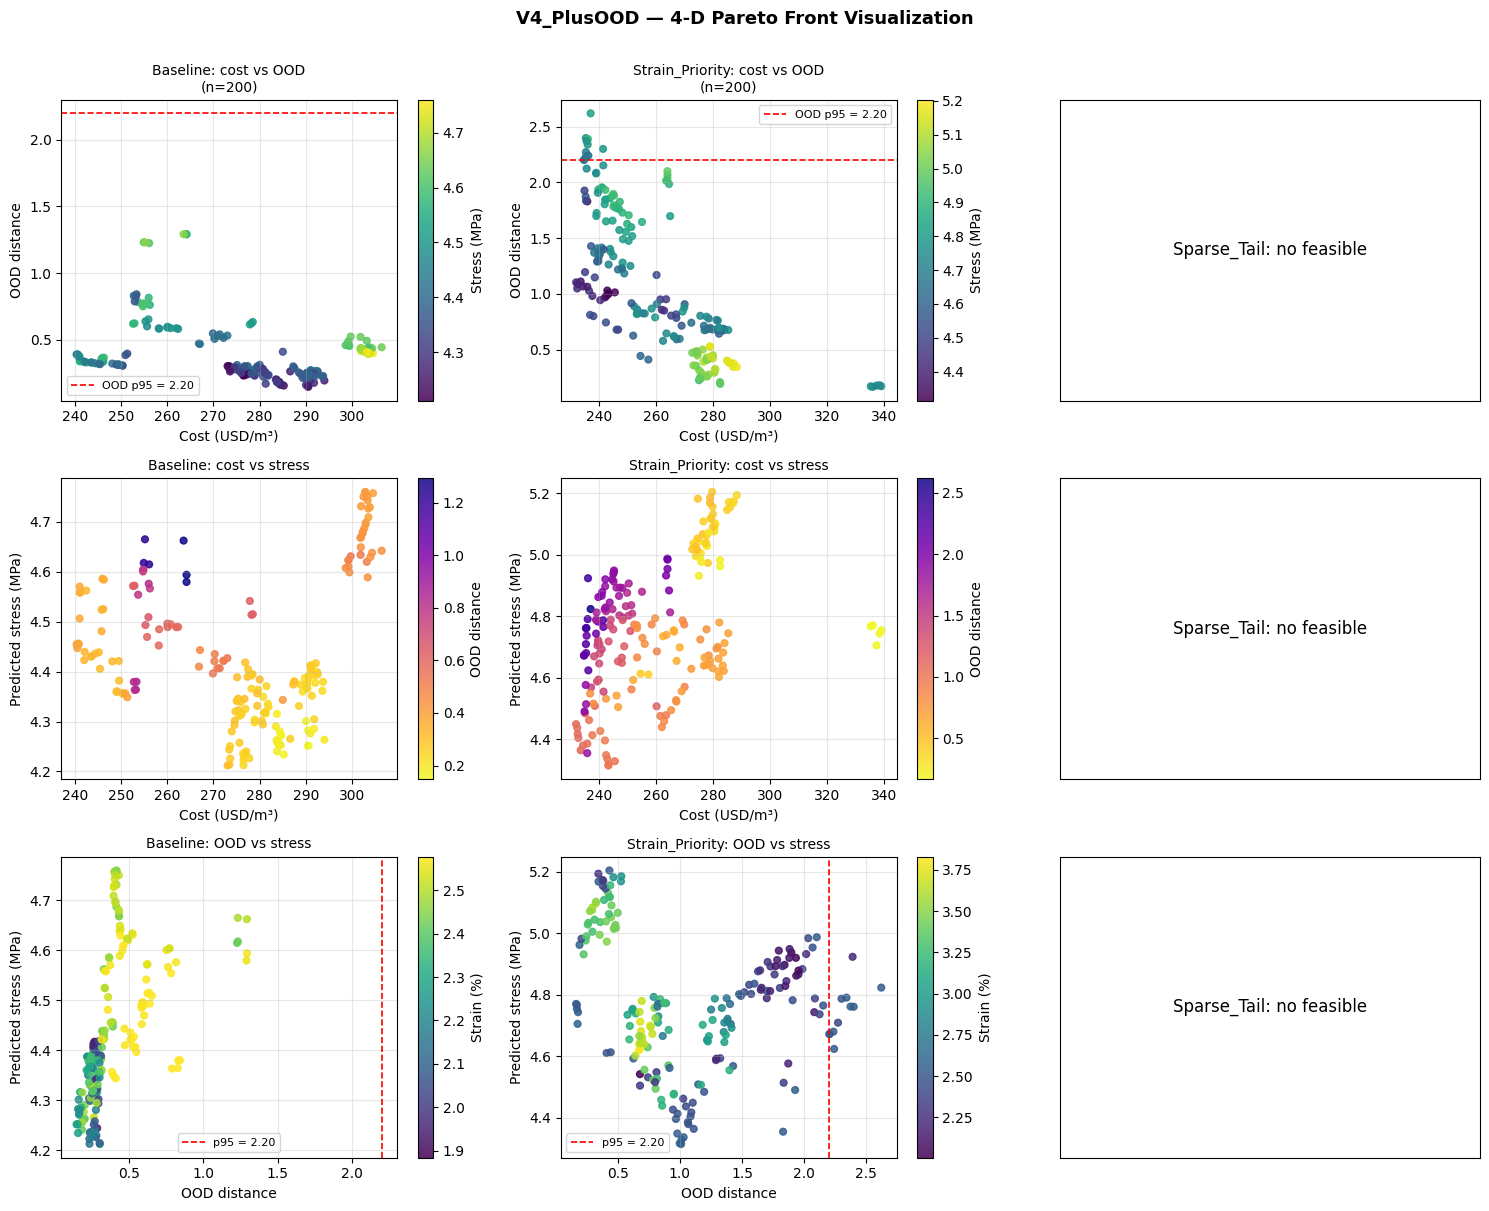

In [37]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for col, (q_name, s_target, e_target) in enumerate(TEST_QUERIES):
    r = v4plusood_results[q_name]
    if r is None or len(r['X']) == 0:
        for row in range(3):
            ax = axes[row, col]
            ax.text(0.5, 0.5, f'{q_name}: no feasible',
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_xticks([]); ax.set_yticks([])
        continue

    # Row 0: cost vs OOD, coloured by stress
    ax = axes[0, col]
    sc = ax.scatter(r['cost'], r['ood_dist'], c=r['q50_s'],
                    cmap='viridis', s=24, alpha=0.85)
    ax.axhline(OOD_DIST_P95, color='red', ls='--', lw=1.2,
               label=f'OOD p95 = {OOD_DIST_P95:.2f}')
    ax.set_xlabel('Cost (USD/m³)'); ax.set_ylabel('OOD distance')
    ax.set_title(f'{q_name}: cost vs OOD\n(n={len(r["X"])})', fontsize=10)
    plt.colorbar(sc, ax=ax, label='Stress (MPa)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Row 1: cost vs stress, coloured by OOD
    ax = axes[1, col]
    sc = ax.scatter(r['cost'], r['q50_s'], c=r['ood_dist'],
                    cmap='plasma_r', s=24, alpha=0.85)
    ax.set_xlabel('Cost (USD/m³)'); ax.set_ylabel('Predicted stress (MPa)')
    ax.set_title(f'{q_name}: cost vs stress', fontsize=10)
    plt.colorbar(sc, ax=ax, label='OOD distance')
    ax.grid(alpha=0.3)

    # Row 2: OOD vs stress, coloured by strain
    ax = axes[2, col]
    sc = ax.scatter(r['ood_dist'], r['q50_s'], c=r['q50_e']*100,
                    cmap='viridis', s=24, alpha=0.85)
    ax.axvline(OOD_DIST_P95, color='red', ls='--', lw=1.2,
               label=f'p95 = {OOD_DIST_P95:.2f}')
    ax.set_xlabel('OOD distance'); ax.set_ylabel('Predicted stress (MPa)')
    ax.set_title(f'{q_name}: OOD vs stress', fontsize=10)
    plt.colorbar(sc, ax=ax, label='Strain (%)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('V4_PlusOOD — 4-D Pareto Front Visualization',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v4_plusood_4d_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 6 — Pick three anchor mixes from the 4-D Pareto

Now that OOD is an objective, we can pick anchor mixes that represent meaningful points on the 4-D front:

- **Conservative**: minimum OOD distance — the most familiar composition that satisfies all constraints.
- **Balanced**: median OOD, median cost — typical recommendation.
- **Aggressive**: highest stress prediction with OOD ≤ p95 — pushes the model's confident ceiling.

These are interpretable choices the user can make based on lab-validation tolerance.

In [38]:
def pick_anchors_4d(r):
    if r is None or len(r['X']) == 0:
        return None
    n = len(r['X'])

    # Conservative: smallest OOD distance
    conservative_idx = int(np.argmin(r['ood_dist']))

    # Aggressive: highest q50_stress among in-distribution mixes
    in_dist_mask = r['ood_dist'] <= OOD_DIST_P95
    if in_dist_mask.any():
        candidates = np.where(in_dist_mask)[0]
        aggressive_idx = int(candidates[np.argmax(r['q50_s'][candidates])])
    else:
        aggressive_idx = int(np.argmax(r['q50_s']))

    # Balanced: median cost, in-distribution
    if in_dist_mask.any():
        cand = np.where(in_dist_mask)[0]
        med_cost = float(np.median(r['cost'][cand]))
        balanced_idx = int(cand[np.argmin(np.abs(r['cost'][cand] - med_cost))])
    else:
        med_cost = float(np.median(r['cost']))
        balanced_idx = int(np.argmin(np.abs(r['cost'] - med_cost)))

    def pack(i):
        return {
            'cost':    float(r['cost'][i]),
            'q50_s':   float(r['q50_s'][i]),  'lo_s': float(r['lo_s'][i]),  'hi_s': float(r['hi_s'][i]),
            'q50_e':   float(r['q50_e'][i]),  'lo_e': float(r['lo_e'][i]),  'hi_e': float(r['hi_e'][i]),
            'ood':     float(r['ood_dist'][i]),
            'mix':     {col: float(r['X'][i][j]) for j, col in enumerate(MIX_INGREDIENT_COLS)},
        }
    return {
        'conservative': pack(conservative_idx),
        'balanced':     pack(balanced_idx),
        'aggressive':   pack(aggressive_idx),
    }


def print_anchor(label, a):
    print(f'\n  {label}')
    print(f'    Cost          : ${a["cost"]:.1f}/m³')
    print(f'    Stress        : q50={a["q50_s"]:.2f} MPa, 80% PI [{a["lo_s"]:.2f}, {a["hi_s"]:.2f}]')
    print(f'    Strain        : q50={a["q50_e"]*100:.2f}%,   80% PI [{a["lo_e"]*100:.2f}, {a["hi_e"]*100:.2f}] %')
    print(f'    OOD distance  : {a["ood"]:.2f}  ({"in-dist" if a["ood"] <= OOD_DIST_P95 else "OUT-of-dist"})')
    print(f'    Mix (kg/m³):')
    for k, v in a['mix'].items():
        print(f'      {k:<22} {v:7.1f}')


for q_name in ['Baseline', 'Strain_Priority', 'Sparse_Tail']:
    print('\n' + '=' * 70)
    print(f'  ANCHOR MIXES — {q_name} query  (V4_PlusOOD 4-D Pareto)')
    print('=' * 70)
    anchors = pick_anchors_4d(v4plusood_results[q_name])
    if anchors is None:
        print('  No feasible solutions — V4_PlusOOD returned empty front.')
        continue
    print_anchor('① Conservative (min OOD distance)', anchors['conservative'])
    print_anchor('② Balanced (median cost, in-distribution)', anchors['balanced'])
    print_anchor('③ Aggressive (max stress, in-distribution)', anchors['aggressive'])


  ANCHOR MIXES — Baseline query  (V4_PlusOOD 4-D Pareto)

  ① Conservative (min OOD distance)
    Cost          : $290.5/m³
    Stress        : q50=4.25 MPa, 80% PI [3.19, 4.95]
    Strain        : q50=2.28%,   80% PI [1.75, 2.95] %
    OOD distance  : 0.15  (in-dist)
    Mix (kg/m³):
      Cement                   382.5
      Water                    297.2
      Sand                     368.3
      Fly ash C                  0.4
      Fly ash F                819.7
      GGBS                       0.4
      Coarse Aggr.               0.0
      Silica Fume                0.1
      Water Reducer/SP          11.0

  ② Balanced (median cost, in-distribution)
    Cost          : $277.9/m³
    Stress        : q50=4.54 MPa, 80% PI [3.56, 4.93]
    Strain        : q50=2.58%,   80% PI [2.22, 2.59] %
    OOD distance  : 0.62  (in-dist)
    Mix (kg/m³):
      Cement                   286.2
      Water                    331.7
      Sand                     493.5
      Fly ash C                 

## 8. Distribution-based recommendation

Replaces the earlier Budget/Standard/Premium tier display. Reports the **cost distribution** across all feasible mixes (median, IQR, 5–95 % range) plus three anchor mixes:

- **Cheapest q50-feasible** — minimum cost (may be a corner-of-the-space sample; flagged as such).
- **Tightest certifying** — narrowest combined 80 % PI width among mixes whose interval fits the target box.
- **Robust median** — closest-to-median-cost mix that also certifies. Most representative of the bulk of safe recommendations.

API: `report_recommendation((s_min_mpa, s_max_mpa), (e_min_pct, e_max_pct))`. Strain in **percent** at the call site, converted to decimal internally.

Target: Stress 3.0–6.0 MPa, Strain 2.0–5.0 %

  Feasible mixes (q50 in box)      : 9,352 / 100,000
  Certifying mixes (80% PI in box) : 183  (2.0% of feasible)

  Cost distribution over feasible mixes:
    Median            $403.4/m³
    IQR (25–75 pct)   $360.4  –  $457.4
    90 % range (5–95) $310.0  –  $543.0
    Min – max         $237.4  –  $688.2

  ① Cheapest q50-feasible mix
    Cost           : $237.4/m³
    Stress         : q50=4.40 MPa, 80% PI [3.39, 5.08]  (width 1.69)
    Strain         : q50=2.33 %,   80% PI [0.89, 3.13] %  (width 2.24)
    Compliance     : ✗ q50 only — 80% PI extends outside target box
    OOD distance   : 2.72  (OUT-of-distribution)
    Binder content : 596 kg/m³  (cap 1693)
    Mix (kg/m³):
      Cement                   259.9
      Water                    148.0
      Sand                      76.8
      Fly ash C                144.2
      Fly ash F                124.5
      GGBS                      66.6
      Coarse Aggr.               0.0
      Si

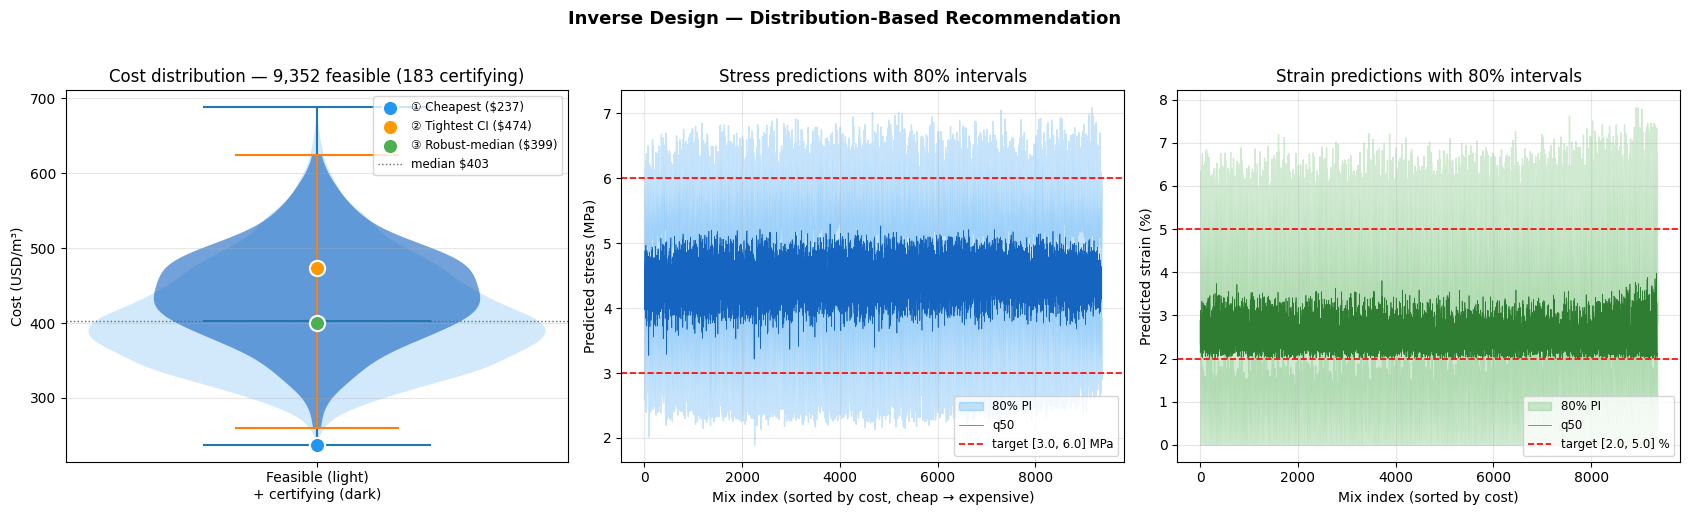

In [39]:
def recommend_mixes(stress_target_mpa, strain_target_pct, n_samples=100_000, seed=SEED):
    rng = np.random.RandomState(seed)
    s_min, s_max = stress_target_mpa
    e_min, e_max = strain_target_pct[0] / 100.0, strain_target_pct[1] / 100.0

    samples = np.column_stack([
        rng.uniform(LB_v2[j], UB_v2[j], n_samples) for j in range(9)
    ])

    rows, psh_s, psh_e, binder = [], [], [], []
    for i in range(n_samples):
        r, ps, pe = build_feature_row(samples[i])
        rows.append(r); psh_s.append(ps); psh_e.append(pe)
        binder.append(samples[i][0]+samples[i][3]+samples[i][4]+samples[i][5]+samples[i][7])
    X_feat = np.vstack(rows)

    lo_s, q50_s, hi_s = predict_with_intervals(X_feat, 'Second Stress')
    lo_e, q50_e, hi_e = predict_with_intervals(X_feat, 'Second Strain')
    psh_s = np.array(psh_s); psh_e = np.array(psh_e); binder = np.array(binder)

    box_ok    = (q50_s >= s_min) & (q50_s <= s_max) & (q50_e >= e_min) & (q50_e <= e_max)
    binder_ok = binder <= BINDER_CAP_99
    feasible  = box_ok & binder_ok

    if feasible.sum() == 0:
        return {'n_feasible': 0, 'cost_stats': None,
                'cheapest': None, 'tightest': None, 'robust': None,
                'feasible_df': None}

    idx = np.where(feasible)[0]
    costs = np.array([mix_cost_v2(samples[i]) for i in idx])
    ood_d, _ = ood_score_batch(samples[idx])

    width_s = hi_s[idx] - lo_s[idx]
    width_e = hi_e[idx] - lo_e[idx]
    combined_width = (width_s / (s_max - s_min)) + (width_e / (e_max - e_min))

    certifies = ((lo_s[idx] >= s_min) & (hi_s[idx] <= s_max) &
                 (lo_e[idx] >= e_min) & (hi_e[idx] <= e_max))

    fdf = pd.DataFrame({
        'cost':   costs,
        'q50_s':  q50_s[idx], 'lo_s': lo_s[idx], 'hi_s': hi_s[idx],
        'q50_e':  q50_e[idx], 'lo_e': lo_e[idx], 'hi_e': hi_e[idx],
        'width_s': width_s,   'width_e': width_e,
        'combined_width': combined_width,
        'certifies': certifies,
        'ood_dist':  ood_d,
        'binder':    binder[idx],
    })
    for j, col in enumerate(MIX_INGREDIENT_COLS):
        fdf[col] = samples[idx, j]

    cost_stats = {
        'median': float(np.median(costs)),
        'p25':    float(np.percentile(costs, 25)),
        'p75':    float(np.percentile(costs, 75)),
        'p5':     float(np.percentile(costs, 5)),
        'p95':    float(np.percentile(costs, 95)),
        'min':    float(costs.min()),
        'max':    float(costs.max()),
    }

    cheapest_idx = fdf['cost'].idxmin()

    cert_subset = fdf[fdf['certifies']]
    if len(cert_subset) > 0:
        tightest_idx = cert_subset['combined_width'].idxmin()
        tightest_cert = True
    else:
        tightest_idx = fdf['combined_width'].idxmin()
        tightest_cert = False

    # Robust-median: closest to median cost among certifying and in-distribution mixes.
    in_dist_cert = cert_subset[cert_subset['ood_dist'] <= OOD_DIST_P95]
    if len(in_dist_cert) > 0:
        robust_pool = in_dist_cert
    elif len(cert_subset) > 0:
        robust_pool = cert_subset
    else:
        robust_pool = fdf
    robust_idx = (robust_pool['cost'] - cost_stats['median']).abs().idxmin()

    return {
        'n_feasible': int(feasible.sum()),
        'cost_stats': cost_stats,
        'cheapest':   fdf.loc[cheapest_idx].to_dict(),
        'tightest':   fdf.loc[tightest_idx].to_dict(),
        'tightest_certifies': tightest_cert,
        'robust':     fdf.loc[robust_idx].to_dict(),
        'feasible_df': fdf,
    }


def _format_anchor(label, anchor, s_target, e_target_dec):
    s_min, s_max = s_target
    e_min, e_max = e_target_dec
    print(f'\n  {label}')
    print(f'    Cost           : ${anchor["cost"]:.1f}/m³')
    print(f'    Stress         : q50={anchor["q50_s"]:.2f} MPa, '
          f'80% PI [{anchor["lo_s"]:.2f}, {anchor["hi_s"]:.2f}]  '
          f'(width {anchor["hi_s"]-anchor["lo_s"]:.2f})')
    print(f'    Strain         : q50={anchor["q50_e"]*100:.2f} %,   '
          f'80% PI [{anchor["lo_e"]*100:.2f}, {anchor["hi_e"]*100:.2f}] %  '
          f'(width {(anchor["hi_e"]-anchor["lo_e"])*100:.2f})')
    inside_s = anchor['lo_s'] >= s_min and anchor['hi_s'] <= s_max
    inside_e = anchor['lo_e'] >= e_min and anchor['hi_e'] <= e_max
    if inside_s and inside_e:
        cert = '✓ certifies (calibrated 80% PI fits target box)'
    else:
        cert = '✗ q50 only — 80% PI extends outside target box'
    print(f'    Compliance     : {cert}')
    print(f'    OOD distance   : {anchor["ood_dist"]:.2f}  '
          f'({"in-distribution" if anchor["ood_dist"] <= OOD_DIST_P95 else "OUT-of-distribution"})')
    print(f'    Binder content : {anchor["binder"]:.0f} kg/m³  (cap {BINDER_CAP_99:.0f})')
    print(f'    Mix (kg/m³):')
    for col in MIX_INGREDIENT_COLS:
        print(f'      {col:<22} {anchor[col]:7.1f}')


def report_recommendation(stress_target_mpa, strain_target_pct, n_samples=100_000):
    print(f'Target: Stress {stress_target_mpa[0]}–{stress_target_mpa[1]} MPa, '
          f'Strain {strain_target_pct[0]:.1f}–{strain_target_pct[1]:.1f} %')
    print('=' * 70)

    out = recommend_mixes(stress_target_mpa, strain_target_pct, n_samples=n_samples)

    if out['n_feasible'] == 0:
        print('No mixes pass all filters. Consider widening targets or relaxing constraints.')
        return out

    cs = out['cost_stats']
    n_cert = int(out['feasible_df']['certifies'].sum())
    n_tot  = out['n_feasible']

    print(f'\n  Feasible mixes (q50 in box)      : {n_tot:,} / {n_samples:,}')
    print(f'  Certifying mixes (80% PI in box) : {n_cert:,}  '
          f'({100*n_cert/n_tot:.1f}% of feasible)')
    print(f'\n  Cost distribution over feasible mixes:')
    print(f'    Median            ${cs["median"]:.1f}/m³')
    print(f'    IQR (25–75 pct)   ${cs["p25"]:.1f}  –  ${cs["p75"]:.1f}')
    print(f'    90 % range (5–95) ${cs["p5"]:.1f}  –  ${cs["p95"]:.1f}')
    print(f'    Min – max         ${cs["min"]:.1f}  –  ${cs["max"]:.1f}')

    e_dec = (strain_target_pct[0]/100, strain_target_pct[1]/100)
    _format_anchor('① Cheapest q50-feasible mix', out['cheapest'],
                   stress_target_mpa, e_dec)
    suffix = '' if out['tightest_certifies'] else '  (none certify; global min width)'
    _format_anchor(f'② Tightest certifying mix{suffix}', out['tightest'],
                   stress_target_mpa, e_dec)
    _format_anchor('③ Robust-median mix (closest to median cost among certifying)',
                   out['robust'], stress_target_mpa, e_dec)
    return out


def plot_recommendation(out, stress_target_mpa, strain_target_pct):
    if out is None or out['n_feasible'] == 0:
        return
    fdf = out['feasible_df']
    cs  = out['cost_stats']
    s_min, s_max = stress_target_mpa
    e_min_pct, e_max_pct = strain_target_pct

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Cost distribution
    ax = axes[0]
    parts = ax.violinplot(fdf['cost'], showmedians=True, widths=0.7)
    for pc in parts['bodies']:
        pc.set_alpha(0.4); pc.set_facecolor('#90CAF9')
    cert_costs = fdf.loc[fdf['certifies'], 'cost'].values
    if len(cert_costs) > 1:
        p2 = ax.violinplot(cert_costs, positions=[1], showmedians=False, widths=0.5)
        for pc in p2['bodies']:
            pc.set_alpha(0.6); pc.set_facecolor('#1565C0')

    ax.scatter([1], [out['cheapest']['cost']], color='#2196F3', s=120, zorder=5,
               edgecolor='white', linewidth=1.5,
               label=f'① Cheapest (${out["cheapest"]["cost"]:.0f})')
    ax.scatter([1], [out['tightest']['cost']], color='#FF9800', s=120, zorder=5,
               edgecolor='white', linewidth=1.5,
               label=f'② Tightest CI (${out["tightest"]["cost"]:.0f})')
    ax.scatter([1], [out['robust']['cost']], color='#4CAF50', s=120, zorder=5,
               edgecolor='white', linewidth=1.5,
               label=f'③ Robust-median (${out["robust"]["cost"]:.0f})')
    ax.axhline(cs['median'], color='#666', ls=':', lw=1, label=f'median ${cs["median"]:.0f}')

    ax.set_xticks([1])
    ax.set_xticklabels(['Feasible (light)\n+ certifying (dark)'])
    ax.set_ylabel('Cost (USD/m³)')
    ax.set_title(f'Cost distribution — {out["n_feasible"]:,} feasible '
                 f'({int(fdf["certifies"].sum()):,} certifying)')
    ax.legend(fontsize=8.5, loc='upper right')
    ax.grid(alpha=0.3, axis='y')

    # Stress predictions sorted by cost
    ax = axes[1]
    order = np.argsort(fdf['cost'].values)
    x = np.arange(len(order))
    ax.fill_between(x, fdf['lo_s'].values[order], fdf['hi_s'].values[order],
                    alpha=0.25, color='#2196F3', label='80% PI')
    ax.plot(x, fdf['q50_s'].values[order], color='#1565C0', lw=0.5, label='q50')
    ax.axhline(s_min, color='red', ls='--', lw=1.2, label=f'target [{s_min}, {s_max}] MPa')
    ax.axhline(s_max, color='red', ls='--', lw=1.2)
    ax.set_xlabel('Mix index (sorted by cost, cheap → expensive)')
    ax.set_ylabel('Predicted stress (MPa)')
    ax.set_title('Stress predictions with 80% intervals')
    ax.legend(fontsize=8.5, loc='lower right')
    ax.grid(alpha=0.3)

    # Strain predictions
    ax = axes[2]
    ax.fill_between(x,
                    fdf['lo_e'].values[order] * 100,
                    fdf['hi_e'].values[order] * 100,
                    alpha=0.25, color='#4CAF50', label='80% PI')
    ax.plot(x, fdf['q50_e'].values[order] * 100, color='#2E7D32', lw=0.5, label='q50')
    ax.axhline(e_min_pct, color='red', ls='--', lw=1.2,
               label=f'target [{e_min_pct:.1f}, {e_max_pct:.1f}] %')
    ax.axhline(e_max_pct, color='red', ls='--', lw=1.2)
    ax.set_xlabel('Mix index (sorted by cost)')
    ax.set_ylabel('Predicted strain (%)')
    ax.set_title('Strain predictions with 80% intervals')
    ax.legend(fontsize=8.5, loc='lower right')
    ax.grid(alpha=0.3)

    plt.suptitle('Inverse Design — Distribution-Based Recommendation',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'inverse_recommendation.png', dpi=150, bbox_inches='tight')
    plt.show()


# Run on the Strain_Priority target window
TARGET_STRESS_MPA = (3.0, 6.0)
TARGET_STRAIN_PCT = (2.0, 5.0)

rec = report_recommendation(TARGET_STRESS_MPA, TARGET_STRAIN_PCT)
plot_recommendation(rec, TARGET_STRESS_MPA, TARGET_STRAIN_PCT)

## 9. Diagnostics

### 9.1 PSH-threshold sensitivity

In [ ]:
# A + B1: PSH sensitivity diagnostic disabled.
# PSH is no longer an active optimization or recommendation constraint.


### 9.2 Achievable-region diagnostic

Sampling 50,000 random mixes for achievable-region estimate ...
  Feasible (binder cap): 5607 / 50000

Achievable range (q50 over feasible region):
  Stress (MPa): 3.30 - 5.27  (mean 4.41)
  Strain (%):   0.48 - 3.63  (mean 2.38)


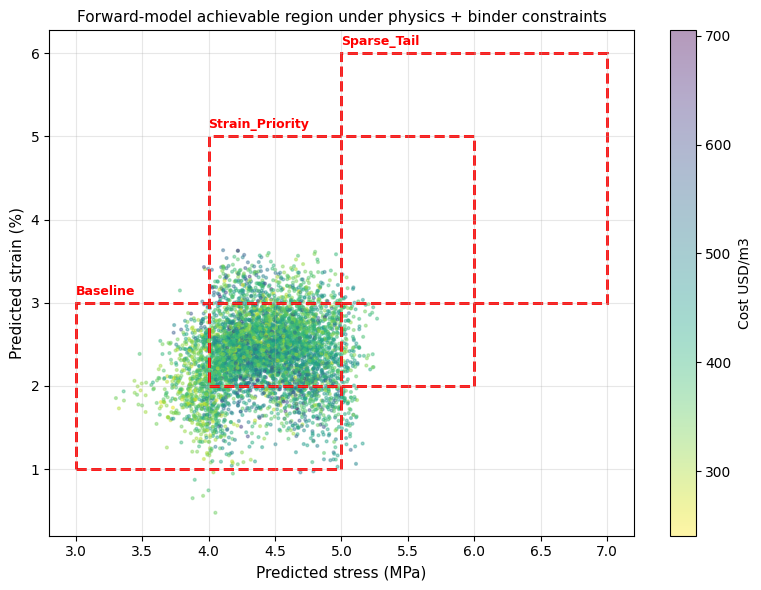

In [40]:
print('Sampling 50,000 random mixes for achievable-region estimate ...')
rng      = np.random.RandomState(SEED)
n_sample = 50_000
mixes    = np.column_stack(
    [rng.uniform(LB_v2[j], UB_v2[j], n_sample) for j in range(9)])

rows3, ps3, pe3, bind3 = [], [], [], []
for i in range(n_sample):
    r, ps, pe = build_feature_row(mixes[i])
    rows3.append(r); ps3.append(ps); pe3.append(pe)
    bind3.append(mixes[i][0]+mixes[i][3]+mixes[i][4]+mixes[i][5]+mixes[i][7])
X_feat3 = np.vstack(rows3)
ps3, pe3, bind3 = np.array(ps3), np.array(pe3), np.array(bind3)

feas3 = bind3 <= BINDER_CAP_99
print(f'  Feasible (binder cap): {feas3.sum()} / {n_sample}')

lo_s3, q50_s3, hi_s3 = predict_with_intervals(X_feat3[feas3], 'Second Stress')
lo_e3, q50_e3, hi_e3 = predict_with_intervals(X_feat3[feas3], 'Second Strain')
costs3 = np.array([mix_cost_v2(mixes[i]) for i in np.where(feas3)[0]])

print(f'\nAchievable range (q50 over feasible region):')
print(f'  Stress (MPa): {q50_s3.min():.2f} - {q50_s3.max():.2f}  (mean {q50_s3.mean():.2f})')
print(f'  Strain (%):   {q50_e3.min()*100:.2f} - {q50_e3.max()*100:.2f}  (mean {q50_e3.mean()*100:.2f})')

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(q50_s3, q50_e3*100, c=costs3, cmap='viridis_r', s=4, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Cost USD/m3')
ax.set_xlabel('Predicted stress (MPa)', fontsize=11)
ax.set_ylabel('Predicted strain (%)', fontsize=11)
ax.set_title('Forward-model achievable region under physics + binder constraints',
             fontsize=11)
for q_name, s_t, e_t in TEST_QUERIES:
    ax.add_patch(plt.Rectangle(
        (s_t[0], e_t[0]*100), s_t[1]-s_t[0], (e_t[1]-e_t[0])*100,
        fill=False, ec='red', lw=2, ls='--'))
    ax.text(s_t[0], e_t[1]*100 + 0.1, q_name, fontsize=9,
            color='red', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'achievable_region.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 OOD distance distribution for V4 Pareto solutions

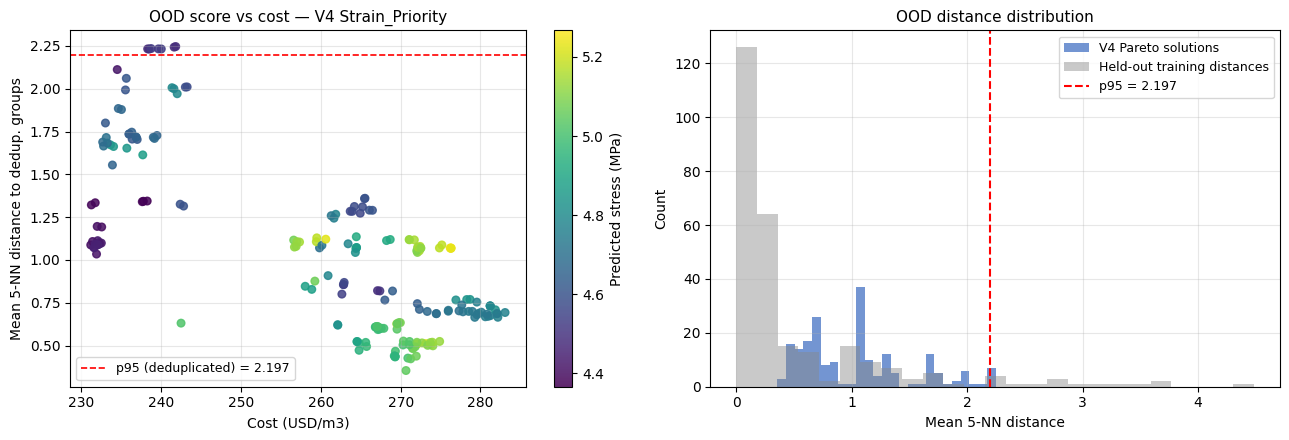

V4 Pareto in-distribution (<=p95): 193/200 (96.5%)


In [41]:
priority_v4 = all_results.get(('V4_NSGA_Uncertainty', 'Strain_Priority'))
if priority_v4 is None or len(priority_v4['X']) == 0:
    print('V4 Strain_Priority result missing or empty — run section 7 first.')
else:
    avg_d, _ = ood_score_batch(priority_v4['X'])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    sc = ax.scatter(priority_v4['cost'], avg_d, c=priority_v4['q50_s'],
                    cmap='viridis', s=30, alpha=0.85)
    ax.axhline(OOD_DIST_P95, color='red', ls='--', lw=1.2,
               label=f'p95 (deduplicated) = {OOD_DIST_P95:.3f}')
    ax.set_xlabel('Cost (USD/m3)', fontsize=10)
    ax.set_ylabel('Mean 5-NN distance to dedup. groups', fontsize=10)
    ax.set_title('OOD score vs cost — V4 Strain_Priority', fontsize=11)
    plt.colorbar(sc, ax=ax, label='Predicted stress (MPa)')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.hist(avg_d, bins=25, color='#4472C4', alpha=0.75, edgecolor='none',
            label='V4 Pareto solutions')
    ax.hist(held_out_5nn, bins=25, color='#888888', alpha=0.45, edgecolor='none',
            label='Held-out training distances')
    ax.axvline(OOD_DIST_P95, color='red', ls='--', lw=1.5,
               label=f'p95 = {OOD_DIST_P95:.3f}')
    ax.set_xlabel('Mean 5-NN distance', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title('OOD distance distribution', fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'ood_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    n_in  = (avg_d <= OOD_DIST_P95).sum()
    n_tot = len(avg_d)
    print(f'V4 Pareto in-distribution (<=p95): {n_in}/{n_tot} ({n_in/n_tot*100:.1f}%)')

## 10. Architecture justification: progressive value of each component

For the defence: each variant in the pipeline isolates one architectural decision.
Reading them in order shows *why* the final pipeline (V4_PlusOOD) looks the way it
does. None of the earlier variants is wrong — each demonstrates the cost of NOT
including a particular component.

| Variant | What it adds | What it isolates |
|---|---|---|
| V1: random sampling | nothing — pure brute force | shows raw feasibility rate (~1% in-distribution for Baseline) |
| V2: NSGA-II unconstrained | gradient-free search | demonstrates NSGA's value over random sampling, but unconstrained NSGA finds physically unrealistic mixes |
| V3: + binder cap + ECC strain baseline | physics constraints | isolates the value of physics filtering — but operates only on q50, ignores uncertainty |
| V4: + interval-aware target constraints | uncertainty propagation | requires the calibrated 80% PI to fit the target box; produces fewer but more confident mixes |
| V4_PlusOOD: + OOD as 4th objective | explicit cost-novelty tradeoff | exposes the cost-of-confidence as a controllable axis rather than a binary filter |

**The progression demonstrates:**
1. NSGA + physics + binder cap (V3) is the standard inverse-design baseline. ~30-100% of its returned mixes are in-distribution, but few have intervals tight enough to certify the target.
2. Adding uncertainty propagation (V4) raises in-distribution rate to ~100% and ensures calibrated confidence, but collapses the front to a narrow cost band.
3. Adding OOD as an objective (V4_PlusOOD) restores the full Pareto-front spread and exposes the cost-vs-novelty tradeoff to the user as an explicit dimension.

**Why this matters over the previous architecture:**
Standard inverse-design papers in this area optimize on point predictions (q50) and
either ignore OOD or apply a post-hoc filter. Both miss the same engineering point:
*the user's risk tolerance is a choice, not a threshold*. By exposing OOD distance
as a Pareto objective rather than a binary filter, the proposed pipeline lets
domain experts pick the operating point that fits their lab-validation budget
without re-running the optimizer.


In [42]:
# Architecture progression summary table for the defence
print("=" * 90)
print("PROGRESSIVE COMPONENT VALUE")
print("=" * 90)

# Use only Baseline (formerly Easy) for the headline table — clearest comparison
q = 'Baseline'
header = f"{'Variant':<22} {'N':>4} {'Cost min':>9} {'Cost max':>9} {'Width_s':>8} {'%InDist':>8}"
print(header)
print("-" * 90)

for variant in ['V1_Random', 'V2_NSGA_Unconstrained', 'V3_NSGA_Physics',
                'V4_NSGA_Uncertainty', 'V5_NSGA_Uncertainty_OOD']:
    row = comp_df[(comp_df['Query'] == q) & (comp_df['Variant'] == variant)].iloc[0]
    n = int(row['N_feasible'])
    if n == 0:
        print(f"{variant:<22} {n:>4} {'--':>9} {'--':>9} {'--':>8} {'--':>8}")
    else:
        print(f"{variant:<22} {n:>4} {row['Cost_min']:>9.1f} {row['Cost_max']:>9.1f} "
              f"{row['Mean_StressWidth']:>8.2f} {row['Pct_InDist']:>7.1f}%")

# V4_PlusOOD row
v4p_easy = v4plusood_results.get('Baseline') or v4plusood_results.get('Easy')
if v4p_easy and len(v4p_easy['X']) > 0:
    n = len(v4p_easy['X'])
    in_dist = (v4p_easy['ood_dist'] <= OOD_DIST_P95).sum()
    width_s = float((v4p_easy['hi_s'] - v4p_easy['lo_s']).mean())
    print(f"{'V4_PlusOOD':<22} {n:>4} {v4p_easy['cost'].min():>9.1f} "
          f"{v4p_easy['cost'].max():>9.1f} {width_s:>8.2f} {100*in_dist/n:>7.1f}%")

print("=" * 90)
print("\nKey transitions (read top-to-bottom):")
print("  V1 -> V2 : NSGA narrows search to box-feasible (78,875 -> 57)")
print("  V2 -> V3 : Physics constraints filter physically unrealistic mixes")
print("  V3 -> V4 : Interval constraints raise %InDist from low to ~100%")
print("  V4 -> V4_PlusOOD : OOD-as-objective opens Pareto spread, exposes tradeoff")
print()
print("V4_PlusOOD subsumes V5 (post-hoc OOD filter):")
print("  When uncertainty is properly propagated, OOD filtering becomes redundant")
print("  because calibrated tight intervals already co-locate with training-data density.")


PROGRESSIVE COMPONENT VALUE
Variant                   N  Cost min  Cost max  Width_s  %InDist
------------------------------------------------------------------------------------------
V1_Random              78378     237.4     831.4     2.63     1.0%
V2_NSGA_Unconstrained    59     211.6     266.5     2.28     8.5%
V3_NSGA_Physics          49     214.1     250.3     2.32    10.2%
V4_NSGA_Uncertainty     180     223.6     313.4     1.34   100.0%
V5_NSGA_Uncertainty_OOD  180     223.6     313.4     1.34   100.0%
V4_PlusOOD              200     240.4     306.5     1.49   100.0%

Key transitions (read top-to-bottom):
  V1 -> V2 : NSGA narrows search to box-feasible (78,875 -> 57)
  V2 -> V3 : Physics constraints filter physically unrealistic mixes
  V3 -> V4 : Interval constraints raise %InDist from low to ~100%
  V4 -> V4_PlusOOD : OOD-as-objective opens Pareto spread, exposes tradeoff

V4_PlusOOD subsumes V5 (post-hoc OOD filter):
  When uncertainty is properly propagated, OOD filtering